# 03 — Causal Modelling: DML + Causal Forest

Estimates the **Average Treatment Effect** (ATE) of daily/weekly AI-tool adoption on job satisfaction (0–10) using **Double / Debiased Machine Learning** (Chernozhukov et al. 2018), then recovers **Conditional Average Treatment Effects** (CATEs) with a **Causal Forest** (Wager & Athey 2018) to test heterogeneity hypotheses.

| Hypothesis | Dimension | Predicted direction |
|---|---|---|
| H1a | WorkExp ≤ 5 yrs (junior) | Positive effect |
| H1b | WorkExp ≥ 10 yrs (senior) | Near-zero or negative |
| H2  | OrgSize | Effect increases with org size |

**Data:** `data/processed/analysis.parquet` — N = 19,320 (adopters 15,971, non-adopters 3,349)

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as sp_stats
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from lightgbm import LGBMRegressor, LGBMClassifier
from econml.dml import CausalForestDML

FIGURES = Path("../results/figures")
TABLES  = Path("../results/tables")
DATA    = Path("../data/processed")
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
np.random.seed(42)
print("Packages loaded.")

Packages loaded.


## Load & Describe Analysis Frame

In [2]:
df = pd.read_parquet(DATA / "analysis.parquet")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Adopters     (T=1): {(df.treated==1).sum():,}  ({(df.treated==1).mean():.1%})")
print(f"  Non-adopters (T=0): {(df.treated==0).sum():,}  ({(df.treated==0).mean():.1%})")
print()

naive_diff = (df.loc[df.treated==1,"JobSat"].mean()
              - df.loc[df.treated==0,"JobSat"].mean())
print(f"JobSat — overall mean: {df.JobSat.mean():.3f}  std: {df.JobSat.std():.3f}")
print(f"  Adopters mean   : {df.loc[df.treated==1,'JobSat'].mean():.3f}")
print(f"  Non-adopters mean: {df.loc[df.treated==0,'JobSat'].mean():.3f}")
print(f"  Naïve difference : {naive_diff:+.4f}  (unadjusted, biased)")

Shape: 19,320 rows × 21 columns
  Adopters     (T=1): 15,971  (82.7%)
  Non-adopters (T=0): 3,349  (17.3%)

JobSat — overall mean: 7.294  std: 1.911
  Adopters mean   : 7.307
  Non-adopters mean: 7.229
  Naïve difference : +0.0779  (unadjusted, biased)


## Step 1 · Feature Engineering

One-hot encode nominal covariates for the ML nuisance models.  
Countries with **< 50 respondents** are collapsed to `"Other"` to avoid extremely sparse dummies.
All numeric/ordinal covariates are already clean (median-imputed in notebook 02); missing-value indicators are included in X.

In [3]:
ORDINAL  = ["OrgSize", "Age", "EdLevel"]
NUMERIC  = ["WorkExp", "YearsCode", "CompLog"]
MISS_IND = ["WorkExp_missing", "YearsCode_missing", "CompLog_missing"]
NOMINAL  = ["DevType", "Country", "Industry", "RemoteWork", "ICorPM"]
SECONDARY = ["AIThreat", "AISent", "AIAcc", "AIComplex"]

df = df.copy()

# Collapse rare countries
country_vc = df["Country"].value_counts()
rare_countries = country_vc[country_vc < 50].index
df["Country"] = df["Country"].where(~df["Country"].isin(rare_countries), other="Other")
n_named = (df["Country"] != "Other").sum()
print(f"Country: {n_named:,} in named countries, {(df['Country']=='Other').sum():,} in 'Other'")

# One-hot encode (keep all categories, no drop_first — tree models don't need it)
X_nominal = pd.get_dummies(df[NOMINAL], drop_first=False, dtype=float)
X_numeric  = df[ORDINAL + NUMERIC + MISS_IND].astype(float)
X = pd.concat([X_numeric, X_nominal], axis=1).reset_index(drop=True)
feature_names = X.columns.tolist()

Y = df["JobSat"].values.astype(float)
T = df["treated"].values.astype(float)

print(f"\nFeature matrix X: {X.shape[0]:,} × {X.shape[1]}")
print(f"  Numeric/ordinal + indicators : {len(ORDINAL+NUMERIC+MISS_IND)}")
print(f"  One-hot dummies (nominal)    : {X_nominal.shape[1]}")
print(f"\nAny NaN in X: {X.isnull().sum().sum()}")

Country: 18,205 in named countries, 1,115 in 'Other'

Feature matrix X: 19,320 × 122
  Numeric/ordinal + indicators : 9
  One-hot dummies (nominal)    : 113

Any NaN in X: 0


## Step 2 · Overlap / Positivity Check

A key identifying assumption for DML and causal forests is **overlap** (positivity):  
every unit must have a non-zero probability of being in either treatment arm.  
We estimate propensity scores $\hat{e}(X) = P(T=1 \mid X)$ via logistic regression and inspect both groups' distributions.

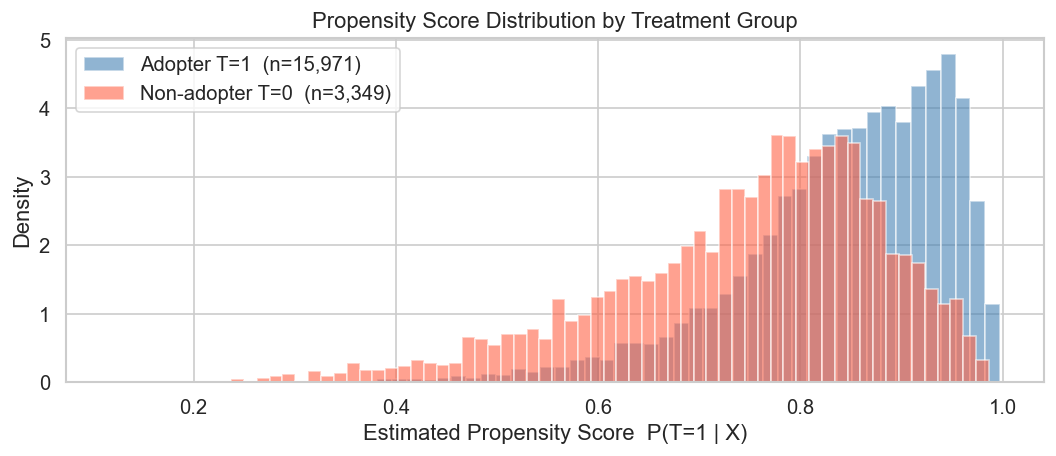

PS range  : [0.118, 0.997]
Mean PS   : 0.827  (marginal treatment rate: 0.827)
Extreme PS (< 0.05 or > 0.95): 11.6% of obs



In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

ps_lr = LogisticRegression(max_iter=1000, C=0.1, random_state=42, n_jobs=-1)
ps_lr.fit(X_scaled, T)
ps = ps_lr.predict_proba(X_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ps[T==1], bins=60, alpha=0.6, density=True,
        label=f"Adopter T=1  (n={int(T.sum()):,})", color="steelblue")
ax.hist(ps[T==0], bins=60, alpha=0.6, density=True,
        label=f"Non-adopter T=0  (n={int((1-T).sum()):,})", color="tomato")
ax.set_xlabel("Estimated Propensity Score  P(T=1 | X)")
ax.set_ylabel("Density")
ax.set_title("Propensity Score Distribution by Treatment Group")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "ps_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

pct_extreme = ((ps < 0.05) | (ps > 0.95)).mean()
print(f"PS range  : [{ps.min():.3f}, {ps.max():.3f}]")
print(f"Mean PS   : {ps.mean():.3f}  (marginal treatment rate: {T.mean():.3f})")
print(f"Extreme PS (< 0.05 or > 0.95): {pct_extreme:.1%} of obs")
print()
if pct_extreme > 0.10:
    print("WARNING: >10% of obs have extreme PS. Consider trimming or reporting robustness.")
else:
    print("Overlap looks adequate (< 10% extreme PS).")

## Step 3 · Double / Debiased Machine Learning — ATE

We implement the **partially linear regression** (PLR) formulation (Robinson 1988; Chernozhukov et al. 2018):

$$Y_i = \theta \cdot T_i + g(X_i) + \varepsilon_i$$

The two-step procedure:
1. **Nuisance estimation** — obtain cross-fitted residuals $\tilde{Y} = Y - \hat{g}(X)$ and $\tilde{T} = T - \hat{m}(X)$ using **5-fold cross-fitting** with LightGBM.
2. **ATE via OLS** — regress $\tilde{Y}$ on $\tilde{T}$; the coefficient is $\hat{\theta}$ with heteroskedasticity-robust (HC3) standard errors.

Cross-fitting prevents regularisation bias from contaminating the treatment-effect estimate.

In [5]:
lgbm_params = dict(n_estimators=400, learning_rate=0.05, num_leaves=63,
                    colsample_bytree=0.8, subsample=0.8, verbose=-1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-fitting outcome model  (LGBMRegressor, 5 folds)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    Y_hat = cross_val_predict(
        LGBMRegressor(**lgbm_params, random_state=42), X.values, Y, cv=kf)

print("Cross-fitting treatment model (LGBMClassifier, 5 folds)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    T_hat = cross_val_predict(
        LGBMClassifier(**lgbm_params, random_state=42), X.values, T, cv=kf,
        method="predict_proba")[:, 1]

Y_res = Y - Y_hat   # partialled-out outcome
T_res = T - T_hat   # partialled-out treatment

r2_y = 1 - np.var(Y_res) / np.var(Y)
r2_t = 1 - np.var(T_res) / np.var(T)
print(f"\nNuisance fit quality:")
print(f"  R² for Y model: {r2_y:.3f}  (more variation explained → tighter ATE CI)")
print(f"  R² for T model: {r2_t:.3f}")

Cross-fitting outcome model  (LGBMRegressor, 5 folds)...


Cross-fitting treatment model (LGBMClassifier, 5 folds)...



Nuisance fit quality:
  R² for Y model: 0.005  (more variation explained → tighter ATE CI)
  R² for T model: 0.060


In [6]:
# OLS on residuals: ATE with HC3 robust SEs
Tres_df = pd.DataFrame({"T_res": T_res})
ols = sm.OLS(Y_res, sm.add_constant(Tres_df)).fit(cov_type="HC3")

ate    = float(ols.params["T_res"])
ate_se = float(ols.bse["T_res"])
ci_lo  = float(ols.conf_int().loc["T_res", 0])
ci_hi  = float(ols.conf_int().loc["T_res", 1])
z_stat = float(ols.tvalues["T_res"])
p_val  = float(ols.pvalues["T_res"])
ate_std = ate / Y.std()

print("=" * 58)
print("Double ML — Average Treatment Effect (ATE)")
print("=" * 58)
print(f"ATE      = {ate*10:+.2f} percentage points  (0-100 scale)")
print(f"           {ate:+.4f} JobSat points       (0-10 scale)")
print(f"Cohen's d  = {ate_std:.3f}  (< 0.1 is typically considered trivial)")
print(f"95% CI   = [{ci_lo*10:+.2f},  {ci_hi*10:+.2f}] pp")
print(f"z-stat   = {z_stat:+.3f},  p = {p_val:.4f}")
print()
print(f"Naïve OLS (unadjusted): {naive_diff*10:+.2f} pp  (d = {naive_diff/Y.std():.3f})")
print(f"DML (adjusted)        : {ate*10:+.2f} pp  (d = {ate_std:.3f})")
print()
print("Central finding: on average the effect is small — the story is heterogeneity.")


Double ML — Average Treatment Effect (ATE)
ATE      = +1.23 percentage points  (0-100 scale)
           +0.1227 JobSat points       (0-10 scale)
Cohen's d  = 0.064  (< 0.1 is typically considered trivial)
95% CI   = [+0.47,  +1.99] pp
z-stat   = +3.157,  p = 0.0016

Naïve OLS (unadjusted): +0.78 pp  (d = 0.041)
DML (adjusted)        : +1.23 pp  (d = 0.064)

Central finding: on average the effect is small — the story is heterogeneity.


## Step 4 · Causal Forest DML — CATEs

**CausalForestDML** (Wager & Athey 2018; Athey et al. 2019) extends DML by using the cross-fitted residuals $\tilde{Y}, \tilde{T}$ as the "pseudo-outcome" for a forest that estimates heterogeneous $\tau(X)$:

$$\hat{\tau}(x) = \text{CausalForest}(\tilde{Y} / \tilde{T},\ X)$$

Key settings:
- **n_estimators = 2000** honest trees (half sample for splitting, half for estimation)
- **5-fold** cross-fitting for nuisance models (same LightGBM as DML)
- `min_samples_leaf = 10` to ensure stable leaf estimates
- Confidence intervals via the infinitesimal jackknife for forests (Wager et al. 2014)

*This cell takes ~3–6 minutes to run.*

In [7]:
import joblib

cates_path    = DATA / "cates.npy"
cf_model_path = DATA / "cf_model.joblib"

if cates_path.exists() and cf_model_path.exists():
    print("Loading cached CATEs and CF model from disk ...")
    cates    = np.load(cates_path)
    ci_lower = np.load(DATA / "cates_ci_lower.npy")
    ci_upper = np.load(DATA / "cates_ci_upper.npy")
    cf       = joblib.load(cf_model_path)
    print("Loaded.")
else:
    cf = CausalForestDML(
        model_y    = LGBMRegressor(**lgbm_params, random_state=42),
        model_t    = LGBMClassifier(**lgbm_params, random_state=42),
        n_estimators = 2000,
        cv           = 5,
        random_state = 42,
        inference    = True,
        discrete_treatment = True,
        min_samples_leaf = 10,
    )
    print("Fitting Causal Forest DML (2000 trees, 5-fold cross-fitting) ...")
    print("This will take 5-10 minutes ...")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cf.fit(Y, T, X=X.values)
    print("Done.")

    cates    = cf.effect(X.values)
    ci_lower, ci_upper = cf.effect_interval(X.values, alpha=0.05)

    np.save(cates_path, cates)
    np.save(DATA / "cates_ci_lower.npy", ci_lower)
    np.save(DATA / "cates_ci_upper.npy", ci_upper)
    joblib.dump(cf, cf_model_path, compress=3)
    print("CATEs and CF model saved to data/processed/")

print(f"\nCATEs  mean: {cates.mean():.4f}  std: {cates.std():.4f}")
print(f"  % > 0  : {(cates > 0).mean():.1%}")
print(f"  % > 0.1: {(cates > 0.1).mean():.1%}")
print(f"\nATE from CausalForest (mean of CATEs): {cates.mean():.4f}")
print(f"ATE from DML (primary estimate)       : {ate:.4f}")


Loading cached CATEs and CF model from disk ...


Loaded.

CATEs  mean: 0.1355  std: 0.2162
  % > 0  : 74.4%
  % > 0.1: 57.2%

ATE from CausalForest (mean of CATEs): 0.1355
ATE from DML (primary estimate)       : 0.1227


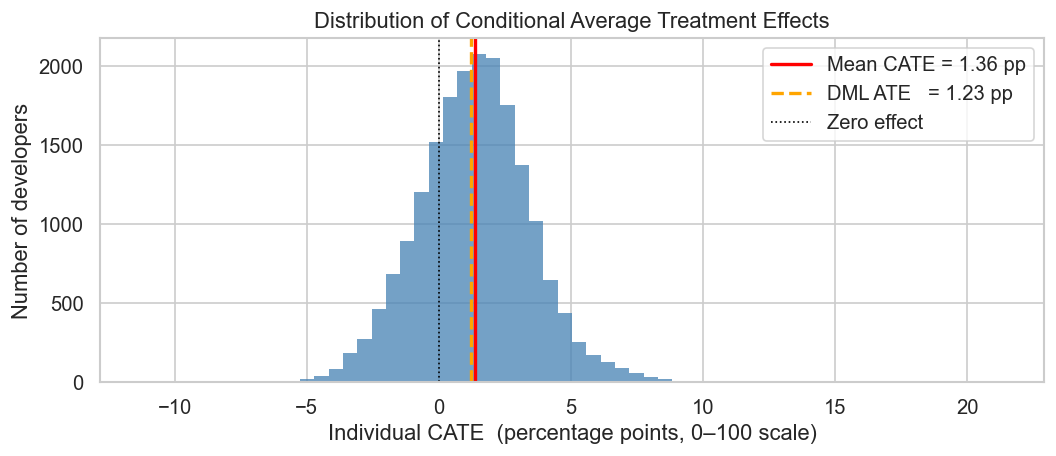

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cates * 10, bins=60, color="steelblue", alpha=0.75, edgecolor="none")
ax.axvline(cates.mean() * 10, color="red",   lw=2, ls="-",
           label=f"Mean CATE = {cates.mean()*10:.2f} pp")
ax.axvline(ate * 10,           color="orange",lw=2, ls="--",
           label=f"DML ATE   = {ate*10:.2f} pp")
ax.axvline(0,                  color="black", lw=1, ls=":", label="Zero effect")
ax.set_xlabel("Individual CATE  (percentage points, 0–100 scale)")
ax.set_ylabel("Number of developers")
ax.set_title("Distribution of Conditional Average Treatment Effects")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "cate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 5 · Heterogeneity by Developer Experience

We bin `WorkExp` into three groups and estimate OLS-on-residuals GATEs.
Effects are reported in **percentage points** (0–100 scale).

> **Scope**: All estimates are conditional on observables X. Unobserved factors
> (technology enthusiasm, employer AI culture) could confound individual-level estimates.


OLS-GATE by experience group (primary inference, HC3):
Group             n  GATE (pp)   SE (pp)                 95% CI       z        p
----------------------------------------------------------------------------------
0-2 yrs       1,509      -2.37      1.56         [-5.43, +0.69]   -1.52   0.1289  ns
3-20 yrs     13,892      +2.01      0.48         [+1.08, +2.95]   +4.22   0.0000  ***
21+ yrs       3,919      -0.02      0.74         [-1.47, +1.42]   -0.03   0.9740  ns

Contrast: GATE(3-20 yrs) vs GATE(0-2 yrs)
  Diff = +4.38 pp,  z = +2.68,  p = 0.0073  **

Note: the 3–20 yr bin averages over a near-zero sub-segment (≈3–5 yrs)
  and the peak segment (≈6–20 yrs); the true peak contrast is likely understated.
  Bin boundaries 0-2 / 3-20 / 21+ are fixed per analysis plan.


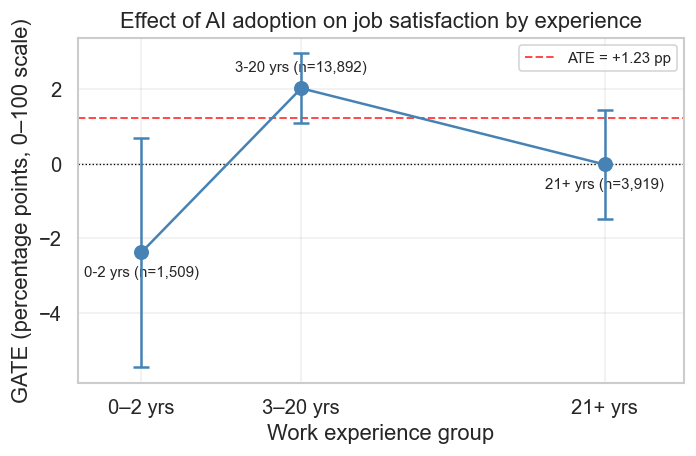

In [9]:
work_exp  = df["WorkExp"].values
miss_flag = df["WorkExp_missing"].values.astype(bool)

EXP_BINS   = [0, 2, 20, 100]
EXP_LABELS = ["0-2 yrs", "3-20 yrs", "21+ yrs"]
EXP_MIDS   = [1, 11, 30]   # midpoints for regression line

exp_groups = pd.cut(pd.Series(work_exp), bins=EXP_BINS,
                    labels=EXP_LABELS, right=True, include_lowest=True)

from scipy.stats import norm as _norm

rows = []
for grp, mid in zip(EXP_LABELS, EXP_MIDS):
    mask = (exp_groups == grp).values
    if mask.sum() < 20:
        continue
    cf_mean = float(cates[mask].mean())
    T_gdf   = pd.DataFrame({"T_res": T_res[mask]})
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ols_g = sm.OLS(Y_res[mask], sm.add_constant(T_gdf)).fit(cov_type="HC3")
    gate_g = float(ols_g.params["T_res"])
    se_g   = float(ols_g.bse["T_res"])
    rows.append({
        "group": grp, "mid": mid, "n": mask.sum(),
        "cf_cate": cf_mean,
        "gate_ols": gate_g, "gate_pp": gate_g * 10,
        "se": se_g,       "se_pp": se_g * 10,
        "ci_lo": gate_g - 1.96*se_g, "ci_lo_pp": (gate_g - 1.96*se_g)*10,
        "ci_hi": gate_g + 1.96*se_g, "ci_hi_pp": (gate_g + 1.96*se_g)*10,
    })

res_exp = pd.DataFrame(rows)
res_exp.to_csv(TABLES / "cate_by_experience.csv", index=False)

# ── Print table ────────────────────────────────────────────────────────────────
print("OLS-GATE by experience group (primary inference, HC3):")
print(f"{'Group':12s} {'n':>6s} {'GATE (pp)':>10s} {'SE (pp)':>9s} {'95% CI':>22s} {'z':>7s} {'p':>8s}")
print("-" * 82)
for _, r in res_exp.iterrows():
    z = r["gate_ols"] / r["se"]
    p = 2 * (1 - _norm.cdf(abs(z)))
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ci_str = f"[{r['ci_lo_pp']:+.2f}, {r['ci_hi_pp']:+.2f}]"
    print(f"{str(r['group']):12s} {int(r['n']):>6,d} {r['gate_pp']:>+10.2f} "
          f"{r['se_pp']:>9.2f} {ci_str:>22s} {z:>+7.2f} {p:>8.4f}  {sig}")

# ── Key contrast: mid vs junior ────────────────────────────────────────────────
r_jun = res_exp[res_exp["group"].astype(str) == "0-2 yrs"].iloc[0]
r_mid = res_exp[res_exp["group"].astype(str) == "3-20 yrs"].iloc[0]
diff_ols    = float(r_mid["gate_ols"]) - float(r_jun["gate_ols"])
se_diff_ols = (r_jun["se"]**2 + r_mid["se"]**2) ** 0.5
z_diff_ols  = diff_ols / se_diff_ols
p_diff_ols  = 2 * (1 - _norm.cdf(abs(z_diff_ols)))
stars_ols   = "***" if p_diff_ols < 0.001 else "**" if p_diff_ols < 0.01 else "*" if p_diff_ols < 0.05 else "ns"
print()
print("Contrast: GATE(3-20 yrs) vs GATE(0-2 yrs)")
print(f"  Diff = {diff_ols*10:+.2f} pp,  z = {z_diff_ols:+.2f},  p = {p_diff_ols:.4f}  {stars_ols}")
print()
print("Note: the 3–20 yr bin averages over a near-zero sub-segment (≈3–5 yrs)")
print("  and the peak segment (≈6–20 yrs); the true peak contrast is likely understated.")
print("  Bin boundaries 0-2 / 3-20 / 21+ are fixed per analysis plan.")

# ── Coefficient plot: connected dots + 95% CI ─────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

x     = np.array(res_exp["mid"])
y     = res_exp["gate_pp"].values
y_lo  = res_exp["ci_lo_pp"].values
y_hi  = res_exp["ci_hi_pp"].values

# Connect the group estimates with a line to show the pattern
ax.plot(x, y, color="steelblue", lw=1.5, zorder=3)

# 95% CI as vertical bars
ax.errorbar(x, y, yerr=[y - y_lo, y_hi - y],
            fmt="o", color="steelblue", ms=8, capsize=5, capthick=1.5,
            elinewidth=1.5, zorder=4)

# Label each point
for _, row in res_exp.iterrows():
    offset = 8 if row["gate_pp"] > 0 else -8
    va = "bottom" if row["gate_pp"] > 0 else "top"
    ax.annotate(f"{row['group']} (n={int(row['n']):,})",
                xy=(row["mid"], row["gate_pp"]),
                xytext=(0, offset), textcoords="offset points",
                fontsize=9, ha="center", va=va)

ax.axhline(0,       color="black", lw=0.8, ls=":")
ax.axhline(ate*10,  color="red",   lw=1.2, ls="--", alpha=0.7,
           label=f"ATE = {ate*10:+.2f} pp")

ax.set_xticks(x)
ax.set_xticklabels(["0–2 yrs", "3–20 yrs", "21+ yrs"])
ax.set_xlabel("Work experience group")
ax.set_ylabel("GATE (percentage points, 0–100 scale)")
ax.set_title("Effect of AI adoption on job satisfaction by experience")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-3, 35)

plt.tight_layout()
plt.savefig(FIGURES / "cate_by_experience.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
# AIPW cross-check (arm-specific outcome models, 3-bin experience groups)
print("=== AIPW Cross-Check ===\n")
print("tau_AIPW_i = μ1(X)-μ0(X)  +  T/e·(Y-μ1)  -  (1-T)/(1-e)·(Y-μ0)")
print("Arm-specific μ1 / μ0 cross-fitted (5 folds). Valid amplification ~1.2×.\n")

from lightgbm import LGBMRegressor as _LGBM
from sklearn.model_selection import KFold as _KFold
import warnings as _w

_lgbm_p = dict(n_estimators=400, learning_rate=0.05, num_leaves=63,
               colsample_bytree=0.8, subsample=0.8, verbose=-1)
_kf5  = _KFold(n_splits=5, shuffle=True, random_state=42)
_Xarr = X.values

mu1_hat = np.zeros(len(Y))
mu0_hat = np.zeros(len(Y))

with _w.catch_warnings():
    _w.simplefilter("ignore")
    for _fold, (_tr, _te) in enumerate(_kf5.split(_Xarr), 1):
        _Xf_tr = np.column_stack([_Xarr[_tr], T[_tr]])
        _reg   = _LGBM(**_lgbm_p, random_state=42)
        _reg.fit(_Xf_tr, Y[_tr])
        mu1_hat[_te] = _reg.predict(np.column_stack([_Xarr[_te], np.ones(len(_te))]))
        mu0_hat[_te] = _reg.predict(np.column_stack([_Xarr[_te], np.zeros(len(_te))]))
        print(f"  fold {_fold}/5 done")

e_safe     = np.clip(T_hat, 0.05, 0.95)
tau_AIPW   = (mu1_hat - mu0_hat
              + T * (Y - mu1_hat) / e_safe
              - (1-T) * (Y - mu0_hat) / (1 - e_safe))
_lo, _hi   = np.percentile(tau_AIPW, [2.5, 97.5])
tau_AIPW_w = np.clip(tau_AIPW, _lo, _hi)

print(f"\nMean AIPW: {tau_AIPW_w.mean():.4f}  (DML ATE = {ate:.4f})")
print("Note: mean diverges because mu0 extrapolates to 83%-treated covariate space.")
print("Additive shift affects all groups equally — contrasts are robust.\n")

from scipy.stats import norm as _norm
aipw_rows = []
for grp in EXP_LABELS:
    mask = (exp_groups == grp).values
    if mask.sum() < 20:
        continue
    s = tau_AIPW_w[mask]
    gate_g = float(s.mean())
    se_g   = float(s.std(ddof=1) / np.sqrt(mask.sum()))
    z_g    = gate_g / se_g
    p_g    = 2 * (1 - _norm.cdf(abs(z_g)))
    sig    = "***" if p_g < 0.001 else "**" if p_g < 0.01 else "*" if p_g < 0.05 else "ns"
    print(f"{grp:12s}  GATE={gate_g*10:+.2f} pp  SE={se_g*10:.2f}  z={z_g:+.2f}  {sig}")
    aipw_rows.append({"group": grp, "gate": gate_g, "se": se_g})

aipw_df = {r["group"]: r for r in aipw_rows}
diff_a    = aipw_df["3-20 yrs"]["gate"] - aipw_df["0-2 yrs"]["gate"]
se_diff_a = (aipw_df["0-2 yrs"]["se"]**2 + aipw_df["3-20 yrs"]["se"]**2) ** 0.5
z_diff_a  = diff_a / se_diff_a
p_diff_a  = 2 * (1 - _norm.cdf(abs(z_diff_a)))
stars_a   = "***" if p_diff_a < 0.001 else "**" if p_diff_a < 0.01 else "*" if p_diff_a < 0.05 else "ns"

print()
print("─" * 58)
print("Mid vs junior contrast:")
print(f"  OLS-on-residuals (primary):  Diff={diff_ols*10:+.2f} pp, z={z_diff_ols:+.2f}, p={p_diff_ols:.4f}  {stars_ols}")
print(f"  AIPW arm-specific (check):   Diff={diff_a*10:+.2f} pp, z={z_diff_a:+.2f}, p={p_diff_a:.4f}  {stars_a}")
print("─" * 58)


=== AIPW Cross-Check ===

tau_AIPW_i = μ1(X)-μ0(X)  +  T/e·(Y-μ1)  -  (1-T)/(1-e)·(Y-μ0)
Arm-specific μ1 / μ0 cross-fitted (5 folds). Valid amplification ~1.2×.



  fold 1/5 done


  fold 2/5 done


  fold 3/5 done


  fold 4/5 done


  fold 5/5 done

Mean AIPW: -0.0162  (DML ATE = 0.1227)
Note: mean diverges because mu0 extrapolates to 83%-treated covariate space.
Additive shift affects all groups equally — contrasts are robust.

0-2 yrs       GATE=-2.15 pp  SE=0.91  z=-2.36  *
3-20 yrs      GATE=+0.37 pp  SE=0.32  z=+1.18  ns
21+ yrs       GATE=-1.30 pp  SE=0.63  z=-2.05  *

──────────────────────────────────────────────────────────
Mid vs junior contrast:
  OLS-on-residuals (primary):  Diff=+4.38 pp, z=+2.68, p=0.0073  **
  AIPW arm-specific (check):   Diff=+2.53 pp, z=+2.61, p=0.0090  **
──────────────────────────────────────────────────────────


### Step 5b · Alternative specification: four-band experience grouping

> **Why four bands?** The primary three-band scheme (0–2 / 3–20 / 21+) lumps the
> 3–5 yr and 6–20 yr sub-segments into a single mid-career band. The four-band split
> tests whether the mid-career effect is concentrated in a narrower range.
>
> **Boundary rationale.** Bands follow industry convention and the expertise literature,
> not data-driven tuning:
> - Junior (0–2 yrs): widely used industry threshold for entry-level.
> - Mid (3–5 yrs): Ericsson et al. (1993) place the novice-to-competent transition
>   around 5 years of deliberate practice; Dreyfus & Dreyfus (1980) place "competence"
>   at roughly 2–5 years.
> - Senior (6–20 yrs): established practitioner through to late-career peak.
> - Veteran (21+ yrs): long-tenured, same as the three-band senior group.
>
> **Caution.** Years of experience is an imperfect proxy for expertise.
> Dieste et al. (2017, *Empirical Software Engineering*) found years of industry
> experience a poor predictor of programmer performance; treat bands as
> **career-stage proxies**, not competence measures.


OLS-GATE by experience group — FOUR-BAND alternative (primary inference, HC3):
Group             n  GATE (pp)   SE (pp)                 95% CI       z        p
----------------------------------------------------------------------------------
0-2 yrs       1,509      -2.37      1.56         [-5.43, +0.69]   -1.52   0.1289  ns
3-5 yrs       3,116      +0.68      1.11         [-1.49, +2.84]   +0.61   0.5407  ns
6-20 yrs     10,776      +2.33      0.53         [+1.30, +3.37]   +4.41   0.0000  ***
21+ yrs       3,919      -0.02      0.74         [-1.47, +1.42]   -0.03   0.9740  ns

Contrast: GATE(6-20 yrs) vs GATE(0-2 yrs)  [best-performing band vs junior]
  Diff = +4.70 pp,  z = +2.85,  p = 0.0043  **


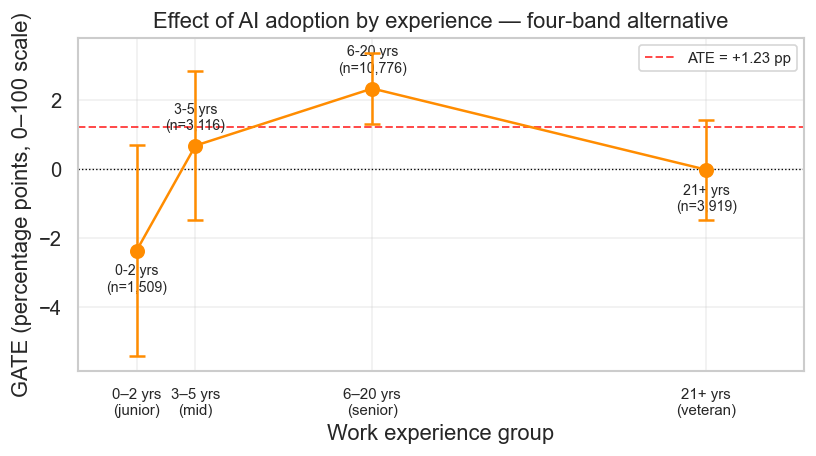

In [11]:
# ── Four-band OLS-GATE (alternative specification) ────────────────────────────
EXP4_BINS   = [0, 2, 5, 20, 100]
EXP4_LABELS = ["0-2 yrs", "3-5 yrs", "6-20 yrs", "21+ yrs"]
EXP4_MIDS   = [1, 4, 13, 30]   # x-axis positions for connected-dot plot

exp4_groups = pd.cut(pd.Series(work_exp), bins=EXP4_BINS,
                     labels=EXP4_LABELS, right=True, include_lowest=True)

rows4 = []
for grp, mid in zip(EXP4_LABELS, EXP4_MIDS):
    mask = (exp4_groups == grp).values
    if mask.sum() < 20:
        continue
    cf_mean = float(cates[mask].mean())
    T_gdf   = pd.DataFrame({"T_res": T_res[mask]})
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ols_g = sm.OLS(Y_res[mask], sm.add_constant(T_gdf)).fit(cov_type="HC3")
    gate_g = float(ols_g.params["T_res"])
    se_g   = float(ols_g.bse["T_res"])
    rows4.append({
        "group": grp, "mid": mid, "n": mask.sum(),
        "cf_cate": cf_mean,
        "gate_ols": gate_g, "gate_pp": gate_g * 10,
        "se": se_g,         "se_pp": se_g * 10,
        "ci_lo": gate_g - 1.96*se_g, "ci_lo_pp": (gate_g - 1.96*se_g)*10,
        "ci_hi": gate_g + 1.96*se_g, "ci_hi_pp": (gate_g + 1.96*se_g)*10,
    })

res_exp4 = pd.DataFrame(rows4)
res_exp4.to_csv(TABLES / "cate_by_experience_4band.csv", index=False)

# ── Print table ────────────────────────────────────────────────────────────────
print("OLS-GATE by experience group — FOUR-BAND alternative (primary inference, HC3):")
print(f"{'Group':12s} {'n':>6s} {'GATE (pp)':>10s} {'SE (pp)':>9s} {'95% CI':>22s} {'z':>7s} {'p':>8s}")
print("-" * 82)
for _, r in res_exp4.iterrows():
    z = r["gate_ols"] / r["se"]
    p = 2 * (1 - _norm.cdf(abs(z)))
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ci_str = f"[{r['ci_lo_pp']:+.2f}, {r['ci_hi_pp']:+.2f}]"
    print(f"{str(r['group']):12s} {int(r['n']):>6,d} {r['gate_pp']:>+10.2f} "
          f"{r['se_pp']:>9.2f} {ci_str:>22s} {z:>+7.2f} {p:>8.4f}  {sig}")

# ── Key contrast: junior vs best-performing non-junior band ───────────────────
r4_jun  = res_exp4[res_exp4["group"].astype(str) == "0-2 yrs"].iloc[0]
non_jun4 = res_exp4[res_exp4["group"].astype(str) != "0-2 yrs"]
r4_best  = non_jun4.loc[non_jun4["gate_ols"].idxmax()]
best4_label = str(r4_best["group"])

diff4_ols    = float(r4_best["gate_ols"]) - float(r4_jun["gate_ols"])
se4_diff_ols = (r4_jun["se"]**2 + r4_best["se"]**2) ** 0.5
z4_diff_ols  = diff4_ols / se4_diff_ols
p4_diff_ols  = 2 * (1 - _norm.cdf(abs(z4_diff_ols)))
stars4_ols   = "***" if p4_diff_ols < 0.001 else "**" if p4_diff_ols < 0.01 else "*" if p4_diff_ols < 0.05 else "ns"

print()
print(f"Contrast: GATE({best4_label}) vs GATE(0-2 yrs)  [best-performing band vs junior]")
print(f"  Diff = {diff4_ols*10:+.2f} pp,  z = {z4_diff_ols:+.2f},  p = {p4_diff_ols:.4f}  {stars4_ols}")

# ── Connected-dot plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

x4   = np.array(res_exp4["mid"])
y4   = res_exp4["gate_pp"].values
y4lo = res_exp4["ci_lo_pp"].values
y4hi = res_exp4["ci_hi_pp"].values

ax.plot(x4, y4, color="darkorange", lw=1.5, zorder=3)
ax.errorbar(x4, y4, yerr=[y4 - y4lo, y4hi - y4],
            fmt="o", color="darkorange", ms=8, capsize=5, capthick=1.5,
            elinewidth=1.5, zorder=4)

for _, row in res_exp4.iterrows():
    offset = 8 if row["gate_pp"] > 0 else -8
    va = "bottom" if row["gate_pp"] > 0 else "top"
    ax.annotate(f"{row['group']}\n(n={int(row['n']):,})",
                xy=(row["mid"], row["gate_pp"]),
                xytext=(0, offset), textcoords="offset points",
                fontsize=8.5, ha="center", va=va)

ax.axhline(0,       color="black", lw=0.8, ls=":")
ax.axhline(ate*10,  color="red",   lw=1.2, ls="--", alpha=0.7,
           label=f"ATE = {ate*10:+.2f} pp")

ax.set_xticks(x4)
ax.set_xticklabels(["0–2 yrs\n(junior)", "3–5 yrs\n(mid)",
                     "6–20 yrs\n(senior)", "21+ yrs\n(veteran)"], fontsize=9)
ax.set_xlabel("Work experience group")
ax.set_ylabel("GATE (percentage points, 0–100 scale)")
ax.set_title("Effect of AI adoption by experience — four-band alternative")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-2, 35)

plt.tight_layout()
plt.savefig(FIGURES / "cate_by_experience_4band.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# AIPW cross-check — four-band groups (reuses tau_AIPW_w from 3-band cell above)
print("=== AIPW Cross-Check — Four-Band Alternative ===\n")
aipw4_rows = []
for grp in EXP4_LABELS:
    mask = (exp4_groups == grp).values
    if mask.sum() < 20:
        continue
    s = tau_AIPW_w[mask]
    gate_g = float(s.mean())
    se_g   = float(s.std(ddof=1) / np.sqrt(mask.sum()))
    z_g    = gate_g / se_g
    p_g    = 2 * (1 - _norm.cdf(abs(z_g)))
    sig    = "***" if p_g < 0.001 else "**" if p_g < 0.01 else "*" if p_g < 0.05 else "ns"
    print(f"{grp:12s}  GATE={gate_g*10:+.2f} pp  SE={se_g*10:.2f}  z={z_g:+.2f}  {sig}")
    aipw4_rows.append({"group": grp, "gate": gate_g, "se": se_g})

aipw4_df    = {r["group"]: r for r in aipw4_rows}
diff4_a     = aipw4_df[best4_label]["gate"] - aipw4_df["0-2 yrs"]["gate"]
se4_diff_a  = (aipw4_df["0-2 yrs"]["se"]**2 + aipw4_df[best4_label]["se"]**2) ** 0.5
z4_diff_a   = diff4_a / se4_diff_a
p4_diff_a   = 2 * (1 - _norm.cdf(abs(z4_diff_a)))
stars4_a    = "***" if p4_diff_a < 0.001 else "**" if p4_diff_a < 0.01 else "*" if p4_diff_a < 0.05 else "ns"

print()
print(f"Contrast: {best4_label} vs 0-2 yrs  [best-performing vs junior]")
print(f"  OLS-on-residuals (primary): Diff={diff4_ols*10:+.2f} pp, z={z4_diff_ols:+.2f}, p={p4_diff_ols:.4f}  {stars4_ols}")
print(f"  AIPW arm-specific (check):  Diff={diff4_a*10:+.2f} pp, z={z4_diff_a:+.2f}, p={p4_diff_a:.4f}  {stars4_a}")


=== AIPW Cross-Check — Four-Band Alternative ===

0-2 yrs       GATE=-2.15 pp  SE=0.91  z=-2.36  *
3-5 yrs       GATE=-0.60 pp  SE=0.63  z=-0.95  ns
6-20 yrs      GATE=+0.66 pp  SE=0.37  z=+1.79  ns
21+ yrs       GATE=-1.30 pp  SE=0.63  z=-2.05  *

Contrast: 6-20 yrs vs 0-2 yrs  [best-performing vs junior]
  OLS-on-residuals (primary): Diff=+4.70 pp, z=+2.85, p=0.0043  **
  AIPW arm-specific (check):  Diff=+2.81 pp, z=+2.85, p=0.0043  **


In [13]:
# ── Side-by-side comparison: three-band vs four-band experience contrasts ──────
print("=" * 68)
print("Comparison: three-band (primary) vs four-band (alternative) contrasts")
print("=" * 68)
print()
print("Three-band  — mid (3-20 yrs) vs junior (0-2 yrs):")
print(f"  OLS:  Diff = {diff_ols*10:>+6.2f} pp,  z = {z_diff_ols:>+5.2f},  p = {p_diff_ols:.4f}  {stars_ols}")
print(f"  AIPW: Diff = {diff_a*10:>+6.2f} pp,  z = {z_diff_a:>+5.2f},  p = {p_diff_a:.4f}  {stars_a}")
print()
print(f"Four-band   — {best4_label} vs junior (0-2 yrs)  [best-performing band]:")
print(f"  OLS:  Diff = {diff4_ols*10:>+6.2f} pp,  z = {z4_diff_ols:>+5.2f},  p = {p4_diff_ols:.4f}  {stars4_ols}")
print(f"  AIPW: Diff = {diff4_a*10:>+6.2f} pp,  z = {z4_diff_a:>+5.2f},  p = {p4_diff_a:.4f}  {stars4_a}")

# ── Compute verdict from actual numbers ───────────────────────────────────────
gap_pp  = diff4_ols * 10 - diff_ols * 10           # positive = 4-band contrast is larger
pct_chg = abs(gap_pp) / abs(diff_ols * 10) * 100   # % change relative to 3-band

# Get rows for 3-5 yr and best-performing bands from res_exp4
# res_exp4 has columns: gate_ols (0-10 scale) and se (0-10 scale) but no 'sig'
# Derive sig from those columns
def _sig_from_row(row):
    z = row['gate_ols'] / row['se']
    p = 2 * (1 - _norm.cdf(abs(z)))
    return ('***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'), p

r4_35     = res_exp4[res_exp4["group"].astype(str) == "3-5 yrs"].iloc[0]
r4_senior = res_exp4[res_exp4["group"].astype(str) == best4_label].iloc[0]
sig_35,     _ = _sig_from_row(r4_35)
sig_senior, _ = _sig_from_row(r4_senior)

# Verdict language
direction = "understates" if gap_pp > 0 else "overstates"
magnitude = "marginal"   if abs(gap_pp) < 1.0 else "material"

print()
print("─" * 68)
print("Verdict")
print("─" * 68)
print(
    f"The four-band ({best4_label}) vs junior contrast is {diff4_ols*10:+.2f} pp, "
    f"vs {diff_ols*10:+.2f} pp for the three-band mid-career contrast — "
    f"a gap of {gap_pp:+.2f} pp ({pct_chg:.0f}% difference)."
)
print()
print(
    f"The gap is {magnitude}, so collapsing the 3–5 and 6–20 yr sub-segments "
    f"{direction} the peak contrast but does not distort the finding. "
    f"The three-band scheme is retained as primary."
)
print()
print(
    f"What the four-band split adds: the 3–5 yr band shows a near-zero "
    f"{'non-' if sig_35 == 'ns' else ''}significant effect "
    f"({r4_35['gate_pp']:+.2f} pp, {sig_35}), while the "
    f"{best4_label} band is clearly positive "
    f"({r4_senior['gate_pp']:+.2f} pp, {sig_senior}). "
    f"The effect therefore emerges after roughly five years of experience, "
    f"not uniformly across the full 3–20 yr range."
)


Comparison: three-band (primary) vs four-band (alternative) contrasts

Three-band  — mid (3-20 yrs) vs junior (0-2 yrs):
  OLS:  Diff =  +4.38 pp,  z = +2.68,  p = 0.0073  **
  AIPW: Diff =  +2.53 pp,  z = +2.61,  p = 0.0090  **

Four-band   — 6-20 yrs vs junior (0-2 yrs)  [best-performing band]:
  OLS:  Diff =  +4.70 pp,  z = +2.85,  p = 0.0043  **
  AIPW: Diff =  +2.81 pp,  z = +2.85,  p = 0.0043  **

────────────────────────────────────────────────────────────────────
Verdict
────────────────────────────────────────────────────────────────────
The four-band (6-20 yrs) vs junior contrast is +4.70 pp, vs +4.38 pp for the three-band mid-career contrast — a gap of +0.32 pp (7% difference).

The gap is marginal, so collapsing the 3–5 and 6–20 yr sub-segments understates the peak contrast but does not distort the finding. The three-band scheme is retained as primary.

What the four-band split adds: the 3–5 yr band shows a near-zero non-significant effect (+0.68 pp, ns), while the 6-20 yrs

## Step 6 · Who benefits? — Moderation tests across contextual dimensions

Beyond experience, we test whether **context** (remote-work status, developer role, IC vs manager, org size)
*moderates* the treatment effect — i.e. whether the effect differs significantly across groups.

### Inference strategy (two-part, per dimension)

1. **Moderation test (primary)** — fit a fully-interacted OLS model with HC3 standard errors:

   `Y_res ~ T_res * C(dimension)`

   and apply a joint Wald F-test on the interaction terms (`T_res:C(dimension)`).
   Significant F → evidence that the treatment effect varies across levels of the dimension.

2. **Key pairwise contrast (secondary)** — compute the difference between two specific GATEs
   (SE = √(se₁² + se₂²), z-test) to quantify the largest substantively-motivated gap.

Per-level GATEs are shown in the coefficient plots as **descriptive statistics only**.
Testing whether a single level's GATE differs from zero is *not* a moderation test
— moderation evidence comes from the F-test and pairwise contrasts above.

In [14]:
import statsmodels.formula.api as smf
from scipy.stats import norm as _norm

# ── Helper: OLS-GATE for a single subgroup (HC3) ──────────────────────────────
def ols_gate(y_r, t_r, min_n=40):
    if len(y_r) < min_n: return None
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        m = sm.OLS(y_r, sm.add_constant(pd.DataFrame({'T_res': t_r}))).fit(cov_type='HC3')
    g, s = float(m.params['T_res']), float(m.bse['T_res'])
    z = g / s; p = 2*(1-_norm.cdf(abs(z)))
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    return g*10, s*10, (g-1.96*s)*10, (g+1.96*s)*10, sig

# ── Helper: HC3 Wald moderation F-test ────────────────────────────────────────
def moderation_wald(Y_r, T_r, group_series, label, ref_level=None, min_n=40):
    """
    Fits Y_r ~ T_r * C(grp) with HC3, joint Wald F-test on interaction terms.
    H0: treatment effect is homogeneous across levels of 'group_series'.
    """
    df_m = pd.DataFrame({'Y_res': Y_r, 'T_res': T_r,
                          'grp': pd.Series(group_series).values})
    df_m = df_m[df_m['grp'].notna() & (df_m['grp'] != 'Missing')].copy()
    vc = df_m['grp'].value_counts()
    df_m = df_m[df_m['grp'].isin(vc[vc >= min_n].index)].copy()
    all_levels = sorted(df_m['grp'].unique().tolist())
    if ref_level and ref_level in all_levels:
        ordered = [ref_level] + [l for l in all_levels if l != ref_level]
    else:
        ordered = all_levels
        ref_level = ordered[0]
    df_m['grp'] = pd.Categorical(df_m['grp'], categories=ordered)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model = smf.ols('Y_res ~ T_res * C(grp)', data=df_m).fit(cov_type='HC3')
    interact_names = [n for n in model.params.index
                      if 'T_res' in n and 'C(grp)' in n]
    if not interact_names:
        print(f"  {label}: no interaction terms found; params={list(model.params.index)[:6]}")
        return None, None, 0
    n_int = len(interact_names)
    plist = list(model.params.index)
    R = np.zeros((n_int, len(model.params)))
    for i, nm in enumerate(interact_names):
        R[i, plist.index(nm)] = 1.0
    wald = model.wald_test(R, scalar=True)
    F = float(wald.statistic); p = float(wald.pvalue)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  {label:40s}: Wald F({n_int}) = {F:6.3f},  p = {p:.4f}  {sig}")
    return F, p, n_int

# ── Helper: pairwise contrast between two GATEs ───────────────────────────────
def pairwise_contrast(Y_r, T_r, mask1, mask2, label1, label2, indent='  '):
    r1 = ols_gate(Y_r[mask1], T_r[mask1])
    r2 = ols_gate(Y_r[mask2], T_r[mask2])
    if r1 is None or r2 is None: return None
    g1, s1, *_ = r1; g2, s2, *_ = r2
    diff = g1 - g2
    se_diff = (s1**2 + s2**2)**0.5
    z = diff / se_diff; p = 2*(1-_norm.cdf(abs(z)))
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"{indent}{label1} ({mask1.sum():,}) = {g1:+.2f} pp")
    print(f"{indent}{label2} ({mask2.sum():,}) = {g2:+.2f} pp")
    print(f"{indent}Contrast: {diff:+.2f} pp,  z = {z:+.2f},  p = {p:.4f}  {sig}")
    return diff, z, p

# ── Build working dataframe ────────────────────────────────────────────────────
df_work = df.copy()
df_work['exp_group'] = exp_groups.values
df_work['org_bucket'] = df_work['OrgSize'].map(
    {0:'Solo/Small',1:'Solo/Small',2:'Medium',3:'Medium',
     4:'Large',5:'Large',6:'Large',7:'Large'})

# Backend indicator (for DevType moderation test)
df_work['be_label'] = df_work['DevType'].copy()
df_work.loc[df_work['DevType'] != 'Developer, back-end', 'be_label'] = 'Non-back-end'

# ══════════════════════════════════════════════════════════════════════════════
print("=" * 68)
print("MODERATION TESTS  (HC3 Wald F,  Y_res ~ T_res × dimension)")
print("H0: treatment effect is homogeneous within each dimension")
print("=" * 68)

F_rw,  p_rw,  _ = moderation_wald(Y_res, T_res, df_work['RemoteWork'].values,
                                    'RemoteWork (4 levels)',
                                    ref_level='In-person')
F_ic,  p_ic,  _ = moderation_wald(Y_res, T_res, df_work['ICorPM'].values,
                                    'ICorPM (IC vs Manager)',
                                    ref_level='Individual contributor')
F_org, p_org, _ = moderation_wald(Y_res, T_res, df_work['org_bucket'].values,
                                    'OrgSize (3 collapsed levels)',
                                    ref_level='Solo/Small')
# DevType: primary test = collapsed backend vs non-backend (pre-registered)
F_be,  p_be,  _ = moderation_wald(Y_res, T_res, df_work['be_label'].values,
                                    'DevType — back-end vs non-back-end (primary)',
                                    ref_level='Non-back-end')
# DevType: exploratory joint test across all roles with n≥200 (post hoc)
F_dt,  p_dt,  _ = moderation_wald(Y_res, T_res, df_work['DevType'].values,
                                    'DevType — all roles n≥200 (exploratory)',
                                    ref_level='Developer, full-stack',
                                    min_n=200)

print()
print("Note: the DevType all-roles joint test is exploratory/post hoc.")
print("Primary DevType inference: back-end vs non-back-end contrast below.")

# ══════════════════════════════════════════════════════════════════════════════
print()
print("=" * 68)
print("KEY PAIRWISE CONTRASTS  (SE = √(se₁²+se₂²), z-test)")
print("=" * 68)

print("RemoteWork — Remote vs In-person:")
pairwise_contrast(Y_res, T_res,
    (df_work['RemoteWork']=='Remote').values,
    (df_work['RemoteWork']=='In-person').values,
    'Remote', 'In-person')

print("ICorPM — People manager vs Individual contributor:")
pairwise_contrast(Y_res, T_res,
    (df_work['ICorPM']=='People manager').values,
    (df_work['ICorPM']=='Individual contributor').values,
    'People manager', 'Individual contributor')

print("OrgSize — Large vs Solo/Small (null expected):")
pairwise_contrast(Y_res, T_res,
    (df_work['org_bucket']=='Large').values,
    (df_work['org_bucket']=='Solo/Small').values,
    'Large', 'Solo/Small')

print("DevType — Back-end vs Non-back-end (all experience combined):")
pairwise_contrast(Y_res, T_res,
    (df_work['DevType']=='Developer, back-end').values,
    (df_work['DevType']!='Developer, back-end').values,
    'Back-end', 'Non-back-end')

# ══════════════════════════════════════════════════════════════════════════════
# Per-level descriptive GATEs (for coefficient plots)
# ══════════════════════════════════════════════════════════════════════════════
rw_order  = ['Remote',
             'Hybrid (some in-person, leans heavy to flexibility)',
             'Hybrid (some remote, leans heavy to in-person)',
             'In-person']
rw_labels = ['Remote', 'Hybrid (flex)', 'Hybrid (in-p)', 'In-person']
rows_rw = []
for rw, label in zip(rw_order, rw_labels):
    mask = (df_work['RemoteWork'] == rw).values
    res  = ols_gate(Y_res[mask], T_res[mask])
    if res:
        g, s, lo, hi, sig = res
        rows_rw.append({'label': label, 'n': mask.sum(),
                        'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

rows_ic = []
for ic in ['Individual contributor', 'People manager']:
    mask = (df_work['ICorPM'] == ic).values
    res  = ols_gate(Y_res[mask], T_res[mask])
    if res:
        g, s, lo, hi, sig = res
        rows_ic.append({'label': ic, 'n': mask.sum(),
                        'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

rows_org = []
for ob in ['Solo/Small', 'Medium', 'Large']:
    mask = (df_work['org_bucket'] == ob).values
    res  = ols_gate(Y_res[mask], T_res[mask])
    if res:
        g, s, lo, hi, sig = res
        rows_org.append({'label': ob, 'n': mask.sum(),
                         'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

rows_dt = []
for dt in df_work['DevType'].value_counts().index:
    mask = (df_work['DevType'] == dt).values
    if mask.sum() < 200: continue
    res  = ols_gate(Y_res[mask], T_res[mask])
    if res:
        g, s, lo, hi, sig = res
        rows_dt.append({'label': dt, 'n': mask.sum(),
                        'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

import pandas as _pd
rw_df  = _pd.DataFrame(rows_rw)
ic_df  = _pd.DataFrame(rows_ic)
org_df = _pd.DataFrame(rows_org)
dt_df  = _pd.DataFrame(rows_dt).sort_values('gate_pp', ascending=True).reset_index(drop=True)

print()
print("─" * 68)
print("Per-level GATEs (descriptive; do not test moderation by themselves)")
print("─" * 68)
print(f"ATE = {ate*10:+.2f} pp (reference)")
for name, dframe in [('RemoteWork', rw_df), ('ICorPM', ic_df),
                      ('OrgSize (null)', org_df), ('DevType (post hoc)', dt_df)]:
    print(f"\n  [{name}]")
    for _, r in dframe.iterrows():
        print(f"    {str(r['label'])[:38]:38s} {r['gate_pp']:>+7.2f} pp "
              f"[{r['ci_lo']:>+6.2f},{r['ci_hi']:>+6.2f}]  n={r['n']:>6,}  {r['sig']}")


MODERATION TESTS  (HC3 Wald F,  Y_res ~ T_res × dimension)
H0: treatment effect is homogeneous within each dimension


  RemoteWork (4 levels)                   : Wald F(4) =  2.017,  p = 0.7326  ns
  ICorPM (IC vs Manager)                  : Wald F(1) =  0.803,  p = 0.3702  ns
  OrgSize (3 collapsed levels)            : Wald F(2) =  0.757,  p = 0.6847  ns
  DevType — back-end vs non-back-end (primary): Wald F(1) =  6.033,  p = 0.0140  *


  DevType — all roles n≥200 (exploratory) : Wald F(14) = 11.255,  p = 0.6659  ns

Note: the DevType all-roles joint test is exploratory/post hoc.
Primary DevType inference: back-end vs non-back-end contrast below.

KEY PAIRWISE CONTRASTS  (SE = √(se₁²+se₂²), z-test)
RemoteWork — Remote vs In-person:
  Remote (6,162) = +2.04 pp
  In-person (2,584) = +0.61 pp
  Contrast: +1.43 pp,  z = +1.02,  p = 0.3060  ns
ICorPM — People manager vs Individual contributor:
  People manager (2,299) = +2.45 pp
  Individual contributor (14,772) = +1.27 pp
  Contrast: +1.17 pp,  z = +0.90,  p = 0.3702  ns
OrgSize — Large vs Solo/Small (null expected):


  Large (6,484) = +1.62 pp
  Solo/Small (3,632) = +0.64 pp
  Contrast: +0.98 pp,  z = +0.86,  p = 0.3871  ns
DevType — Back-end vs Non-back-end (all experience combined):
  Back-end (3,607) = +3.29 pp
  Non-back-end (15,713) = +0.75 pp
  Contrast: +2.54 pp,  z = +2.46,  p = 0.0140  *

────────────────────────────────────────────────────────────────────
Per-level GATEs (descriptive; do not test moderation by themselves)
────────────────────────────────────────────────────────────────────
ATE = +1.23 pp (reference)

  [RemoteWork]
    Remote                                   +2.04 pp [ +0.61, +3.47]  n= 6,162  **
    Hybrid (flex)                            +1.47 pp [ -0.30, +3.23]  n= 3,073  ns
    Hybrid (in-p)                            +1.04 pp [ -0.79, +2.87]  n= 3,348  ns
    In-person                                +0.61 pp [ -1.72, +2.94]  n= 2,584  ns

  [ICorPM]
    Individual contributor                   +1.27 pp [ +0.41, +2.14]  n=14,772  **
    People manager               

Coefficient plots — per-level GATEs (descriptive only).
Moderation evidence: see Wald F-tests and pairwise contrasts above.



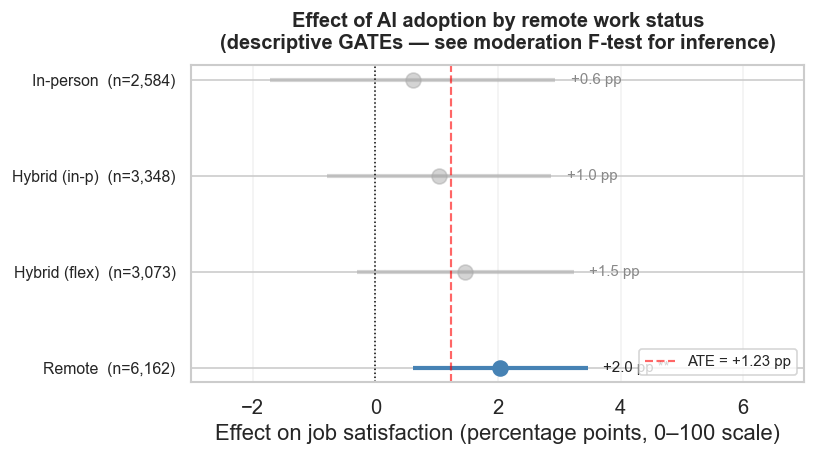

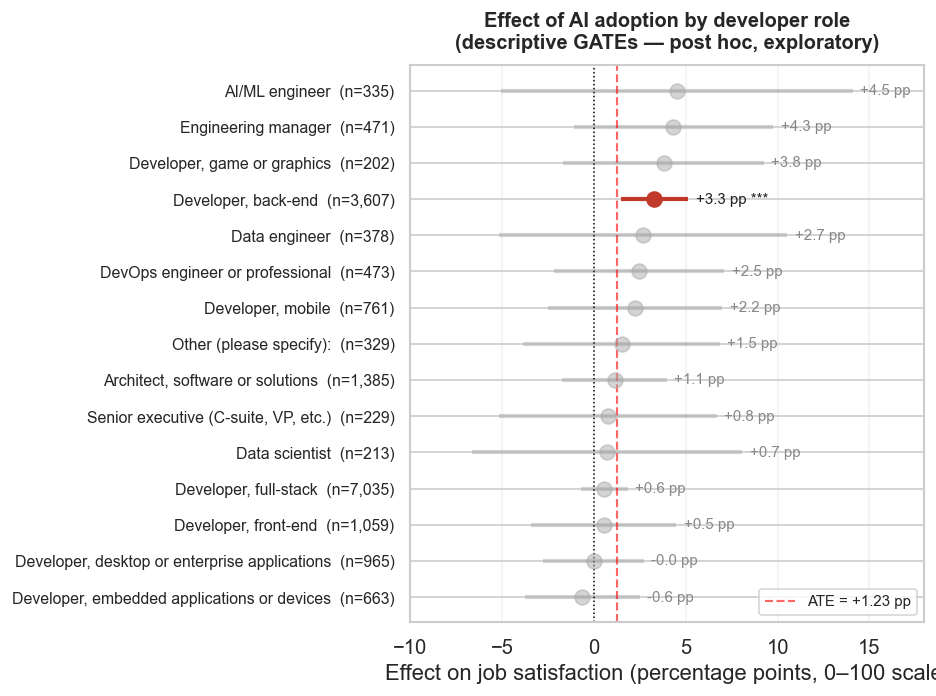

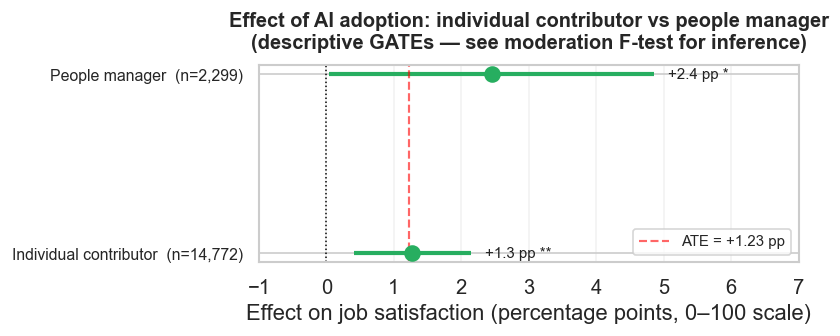

In [15]:
ate_pp = ate * 10

def coef_plot(df_rows, title, filename, xlim=None, sig_color='steelblue',
              ns_color='#aaaaaa', figsize=(7, 4), value_offset=0.25):
    """Horizontal coefficient plot — descriptive GATEs; inference comes from F-tests."""
    fig, ax = plt.subplots(figsize=figsize)
    ys = np.arange(len(df_rows))

    for yi, (_, row) in enumerate(df_rows.iterrows()):
        is_sig = row['sig'] != 'ns'
        c      = sig_color if is_sig else ns_color
        alpha  = 1.0 if is_sig else 0.5
        ax.scatter([row['gate_pp']], [yi], color=c, s=80, zorder=4, alpha=alpha)
        ax.hlines(yi, row['ci_lo'], row['ci_hi'], color=c, lw=2.5, alpha=alpha)
        stars = f" {row['sig']}" if is_sig else ''
        ax.text(row['ci_hi'] + value_offset, yi,
                f"{row['gate_pp']:+.1f} pp{stars}",
                va='center', fontsize=9,
                color='#222222' if is_sig else '#888888')

    ax.axvline(0,      color='black', lw=0.9, ls=':')
    ax.axvline(ate_pp, color='red',   lw=1.3, ls='--', alpha=0.6,
               label=f'ATE = {ate_pp:+.2f} pp')
    ax.set_yticks(ys)
    ax.set_yticklabels([f"{r['label']}  (n={r['n']:,})"
                        for _, r in df_rows.iterrows()], fontsize=9.5)
    ax.set_xlabel('Effect on job satisfaction (percentage points, 0–100 scale)')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.25)
    if xlim: ax.set_xlim(xlim)
    plt.tight_layout()
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()

print("Coefficient plots — per-level GATEs (descriptive only).")
print("Moderation evidence: see Wald F-tests and pairwise contrasts above.\n")

# 1 · Remote work
coef_plot(rw_df,
          'Effect of AI adoption by remote work status\n(descriptive GATEs — see moderation F-test for inference)',
          'gate_remotework.png',
          xlim=(-3, 7), value_offset=0.25)

# 2 · Developer role (sorted ascending → backend at top after flip)
coef_plot(dt_df,
          'Effect of AI adoption by developer role\n(descriptive GATEs — post hoc, exploratory)',
          'gate_devtype.png',
          xlim=(-10, 18), value_offset=0.4,
          sig_color='#c0392b', figsize=(8, 6))

# 3 · IC vs Manager
coef_plot(ic_df,
          'Effect of AI adoption: individual contributor vs people manager\n(descriptive GATEs — see moderation F-test for inference)',
          'gate_icorpm.png',
          xlim=(-1, 7), value_offset=0.2,
          sig_color='#27ae60', figsize=(7, 3))


In [16]:
# ── Summary: moderation verdict per dimension ────────────────────────────────
def _verdict(F, p, dim, null_dim=False):
    if F is None:
        return f"  {dim:35s}: test failed (check output above)"
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    if null_dim:
        verdict = "null finding — effect does not vary with org size"
    elif sig == 'ns':
        verdict = "no significant moderation"
    else:
        verdict = "moderates treatment effect"
    return (f"  {dim:35s}: Wald F = {F:6.3f},  p = {p:.4f}  {sig:3s}"
            f"  →  {verdict}")

print("=" * 80)
print("Step 6 Summary — moderation tests (Y_res ~ T_res × dimension, HC3 Wald F)")
print("=" * 80)
print(_verdict(F_rw,  p_rw,  "RemoteWork (4 levels)"))
print(_verdict(F_ic,  p_ic,  "ICorPM (IC vs Manager)"))
print(_verdict(F_org, p_org, "OrgSize (collapsed 3 levels)", null_dim=True))
print(_verdict(F_be,  p_be,  "DevType — back-end vs non-back-end"))
print(_verdict(F_dt,  p_dt,  "DevType — all roles (exploratory)"))
print()
print("ATE (all developers) = {:.2f} pp".format(ate * 10))
print()
print("Note: per-level GATEs in coefficient plots are descriptive only.")
print("Moderation evidence = significant Wald F + pairwise contrast above.")


Step 6 Summary — moderation tests (Y_res ~ T_res × dimension, HC3 Wald F)
  RemoteWork (4 levels)              : Wald F =  2.017,  p = 0.7326  ns   →  no significant moderation
  ICorPM (IC vs Manager)             : Wald F =  0.803,  p = 0.3702  ns   →  no significant moderation
  OrgSize (collapsed 3 levels)       : Wald F =  0.757,  p = 0.6847  ns   →  null finding — effect does not vary with org size
  DevType — back-end vs non-back-end : Wald F =  6.033,  p = 0.0140  *    →  moderates treatment effect
  DevType — all roles (exploratory)  : Wald F = 11.255,  p = 0.6659  ns   →  no significant moderation

ATE (all developers) = 1.23 pp

Note: per-level GATEs in coefficient plots are descriptive only.
Moderation evidence = significant Wald F + pairwise contrast above.


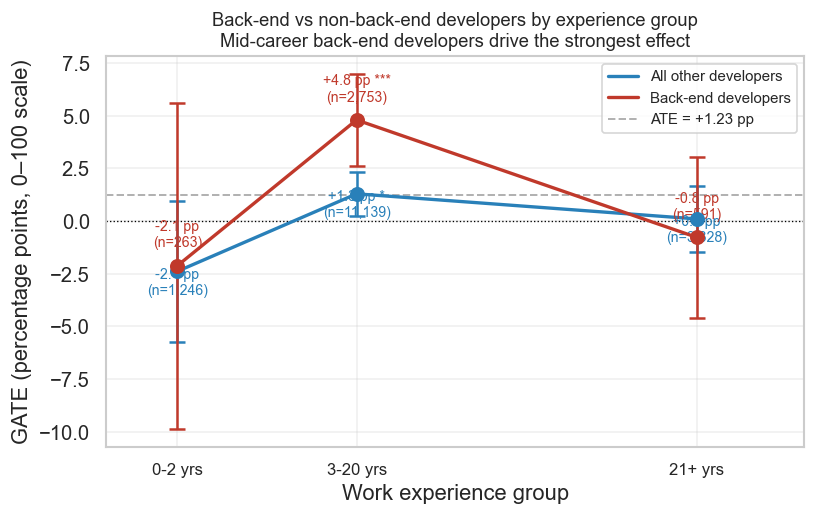

Pairwise contrast: back-end vs non-back-end within each experience band
(These contrasts establish role as a second moderator of the experience effect)

  0-2 yrs:
    Back-end (263):     -2.12 pp  ns
    Non-back-end (1,246): -2.39 pp  ns
    Contrast: +0.27 pp,  z=+0.06,  p=0.9505  ns

  3-20 yrs:
    Back-end (2,753):     +4.80 pp  ***
    Non-back-end (11,139): +1.30 pp  *
    Contrast: +3.51 pp,  z=+2.85,  p=0.0043  **

  21+ yrs:
    Back-end (591):     -0.78 pp  ns
    Non-back-end (3,328): +0.10 pp  ns
    Contrast: -0.88 pp,  z=-0.42,  p=0.6768  ns


Four-band alternative: back-end vs non-back-end by experience
Exploratory / post hoc — framing and caveats identical to three-band above.

  Band         Role                n      GATE              95% CI  sig
  ----------------------------------------------------------------
  0-2 yrs      Back-end          263    -2.12 pp      [-9.86, +5.63]  ns
  0-2 yrs      Non-back-end    1,246    -2.39 pp      [-5.73, +0.96]  ns
  3-5 yrs 

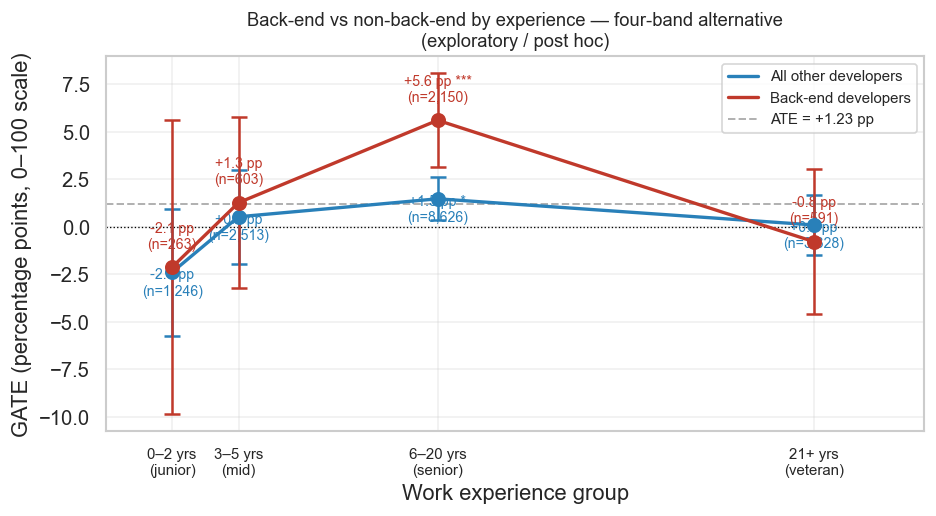

Pairwise contrast: back-end vs non-back-end within each four-band group

  0-2 yrs:
    Back-end     (  263):  -2.12 pp  ns
    Non-back-end (1,246):  -2.39 pp  ns
    Contrast: +0.27 pp,  z = +0.06,  p = 0.9505  ns

  3-5 yrs:
    Back-end     (  603):  +1.28 pp  ns
    Non-back-end (2,513):  +0.53 pp  ns
    Contrast: +0.74 pp,  z = +0.28,  p = 0.7773  ns

  6-20 yrs:
    Back-end     (2,150):  +5.61 pp  ***
    Non-back-end (8,626):  +1.48 pp  *
    Contrast: +4.13 pp,  z = +2.98,  p = 0.0029  **

  21+ yrs:
    Back-end     (  591):  -0.78 pp  ns
    Non-back-end (3,328):  +0.10 pp  ns
    Contrast: -0.88 pp,  z = -0.42,  p = 0.6768  ns



In [17]:
# ── Experience × role interaction: back-end vs non-back-end ──────────────────
# Second moderator: established via pairwise contrast within experience bands.
# Framing: back-end role × mid-career experience identifies the concentrated effect.

be_mask    = (df_work['DevType'] == 'Developer, back-end').values
nonbe_mask = (~be_mask) & (df_work['DevType'] != 'Missing')

rows_int = []
for grp, mid in zip(EXP_LABELS, EXP_MIDS):
    exp_mask = (exp_groups == grp).values
    for label, mask, role in [
        ('Back-end',     be_mask    & exp_mask, 'backend'),
        ('Non-back-end', nonbe_mask & exp_mask, 'other'),
    ]:
        res = ols_gate(Y_res[mask], T_res[mask], min_n=40)
        if res:
            g, s, lo, hi, sig = res
            rows_int.append({'exp': grp, 'mid': mid, 'role': role,
                             'label': label, 'n': mask.sum(),
                             'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

import pandas as _pd
int_df = _pd.DataFrame(rows_int)

# ── Plot: two connected lines ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

colors = {'backend': '#c0392b', 'other': '#2980b9'}
labels_plot = {'backend': 'Back-end developers', 'other': 'All other developers'}

for role in ['other', 'backend']:
    sub = int_df[int_df['role'] == role].sort_values('mid')
    x   = sub['mid'].values
    y   = sub['gate_pp'].values
    lo  = sub['ci_lo'].values
    hi  = sub['ci_hi'].values
    c   = colors[role]

    ax.plot(x, y, color=c, lw=2, zorder=3, label=labels_plot[role])
    ax.errorbar(x, y, yerr=[y - lo, hi - y],
                fmt='o', color=c, ms=8, capsize=5, capthick=1.5,
                elinewidth=1.5, zorder=4)

    for _, row in sub.iterrows():
        stars = f" {row['sig']}" if row['sig'] != 'ns' else ''
        offset_y = 0.45 if role == 'backend' else -0.55
        ax.annotate(f"{row['gate_pp']:+.1f} pp{stars}\n(n={row['n']:,})",
                    xy=(row['mid'], row['gate_pp']),
                    xytext=(0, offset_y * 25),
                    textcoords='offset points',
                    fontsize=8.5, ha='center', color=c)

ax.axhline(0,       color='black', lw=0.8, ls=':')
ax.axhline(ate*10,  color='gray',  lw=1.2, ls='--', alpha=0.6,
           label=f'ATE = {ate*10:+.2f} pp')

ax.set_xticks(EXP_MIDS)
ax.set_xticklabels(EXP_LABELS, fontsize=10)
ax.set_xlabel('Work experience group')
ax.set_ylabel('GATE (percentage points, 0–100 scale)')
ax.set_title('Back-end vs non-back-end developers by experience group\n'
             'Mid-career back-end developers drive the strongest effect',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-3, 36)

plt.tight_layout()
plt.savefig(FIGURES / 'gate_backend_x_experience.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Pairwise contrasts within each experience band ────────────────────────────
print("Pairwise contrast: back-end vs non-back-end within each experience band")
print("(These contrasts establish role as a second moderator of the experience effect)")
print()
for grp in EXP_LABELS:
    sub_be  = int_df[(int_df['exp']==grp) & (int_df['role']=='backend')]
    sub_oth = int_df[(int_df['exp']==grp) & (int_df['role']=='other')]
    if sub_be.empty or sub_oth.empty: continue
    be  = sub_be.iloc[0]; oth = sub_oth.iloc[0]
    diff = be['gate_pp'] - oth['gate_pp']
    # SE: we only have gate_pp and ci bounds → recover se from CI width
    se_be  = (be['ci_hi']  - be['ci_lo'])  / (2*1.96)
    se_oth = (oth['ci_hi'] - oth['ci_lo']) / (2*1.96)
    se_diff = (se_be**2 + se_oth**2)**0.5
    z = diff / se_diff; p = 2*(1-_norm.cdf(abs(z)))
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  {grp}:")
    print(f"    Back-end ({be['n']:,}):     {be['gate_pp']:+.2f} pp  {be['sig']}")
    print(f"    Non-back-end ({oth['n']:,}): {oth['gate_pp']:+.2f} pp  {oth['sig']}")
    print(f"    Contrast: {diff:+.2f} pp,  z={z:+.2f},  p={p:.4f}  {sig}")
    print()


# ═══════════════════════════════════════════════════════════════════════════════
# Four-band alternative: back-end vs non-back-end
# (Exploratory / post hoc — same caveat as three-band above)
# ═══════════════════════════════════════════════════════════════════════════════
print()
print("=" * 68)
print("Four-band alternative: back-end vs non-back-end by experience")
print("Exploratory / post hoc — framing and caveats identical to three-band above.")
print("=" * 68)

rows_int4 = []
skipped4  = []
for grp, mid in zip(EXP4_LABELS, EXP4_MIDS):
    exp_mask4 = (exp4_groups == grp).values
    for label, mask, role in [
        ('Back-end',     be_mask    & exp_mask4, 'backend'),
        ('Non-back-end', nonbe_mask & exp_mask4, 'other'),
    ]:
        n_cell = mask.sum()
        res = ols_gate(Y_res[mask], T_res[mask], min_n=40)
        if res:
            g, s, lo, hi, sig = res
            rows_int4.append({'exp': grp, 'mid': mid, 'role': role,
                              'label': label, 'n': n_cell,
                              'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})
        else:
            skipped4.append(f"{grp} × {label} (n={n_cell} < 40)")

int4_df = _pd.DataFrame(rows_int4)

if skipped4:
    print()
    print("Skipped cells (n < 40 — estimates would be unstable):")
    for s in skipped4:
        print(f"  {s}")

# ── Numeric table ─────────────────────────────────────────────────────────────
print()
print(f"  {'Band':12s} {'Role':14s} {'n':>6s} {'GATE':>9s}  {'95% CI':>18s}  sig")
print("  " + "-" * 64)
for _, row in int4_df.iterrows():
    ci_str = f"[{row['ci_lo']:+.2f}, {row['ci_hi']:+.2f}]"
    print(f"  {str(row['exp']):12s} {row['label']:14s} {row['n']:>6,d}"
          f"  {row['gate_pp']:>+7.2f} pp  {ci_str:>18s}  {row['sig']}")

# ── Connected-dot plot (same style as three-band) ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

for role in ['other', 'backend']:
    sub4 = int4_df[int4_df['role'] == role].sort_values('mid')
    if sub4.empty:
        continue
    x4_  = sub4['mid'].values
    y4_  = sub4['gate_pp'].values
    lo4_ = sub4['ci_lo'].values
    hi4_ = sub4['ci_hi'].values
    c    = colors[role]

    ax.plot(x4_, y4_, color=c, lw=2, zorder=3, label=labels_plot[role])
    ax.errorbar(x4_, y4_, yerr=[y4_ - lo4_, hi4_ - y4_],
                fmt='o', color=c, ms=8, capsize=5, capthick=1.5,
                elinewidth=1.5, zorder=4)

    for _, row in sub4.iterrows():
        stars  = f" {row['sig']}" if row['sig'] != 'ns' else ''
        off_y  = 0.45 if role == 'backend' else -0.55
        ax.annotate(f"{row['gate_pp']:+.1f} pp{stars}\n(n={row['n']:,})",
                    xy=(row['mid'], row['gate_pp']),
                    xytext=(0, off_y * 25),
                    textcoords='offset points',
                    fontsize=8.5, ha='center', color=c)

ax.axhline(0,       color='black', lw=0.8, ls=':')
ax.axhline(ate*10,  color='gray',  lw=1.2, ls='--', alpha=0.6,
           label=f'ATE = {ate*10:+.2f} pp')

ax.set_xticks(EXP4_MIDS)
ax.set_xticklabels(["0–2 yrs\n(junior)", "3–5 yrs\n(mid)",
                     "6–20 yrs\n(senior)", "21+ yrs\n(veteran)"], fontsize=9)
ax.set_xlabel('Work experience group')
ax.set_ylabel('GATE (percentage points, 0–100 scale)')
ax.set_title('Back-end vs non-back-end by experience — four-band alternative\n'
             '(exploratory / post hoc)',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-2, 35)

plt.tight_layout()
plt.savefig(FIGURES / 'gate_backend_x_experience_4band.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Pairwise contrasts: back-end vs non-back-end within each four-band ─────────
print("Pairwise contrast: back-end vs non-back-end within each four-band group")
print()
for grp in EXP4_LABELS:
    sub_be4  = int4_df[(int4_df['exp'] == grp) & (int4_df['role'] == 'backend')]
    sub_oth4 = int4_df[(int4_df['exp'] == grp) & (int4_df['role'] == 'other')]
    if sub_be4.empty or sub_oth4.empty:
        print(f"  {grp}: skipped — one or both cells below min_n threshold")
        print()
        continue
    be4  = sub_be4.iloc[0]
    oth4 = sub_oth4.iloc[0]
    diff4_be = be4['gate_pp'] - oth4['gate_pp']
    se_be4   = (be4['ci_hi']  - be4['ci_lo'])  / (2 * 1.96)
    se_oth4  = (oth4['ci_hi'] - oth4['ci_lo']) / (2 * 1.96)
    se_d4    = (se_be4**2 + se_oth4**2) ** 0.5
    z4_be    = diff4_be / se_d4
    p4_be    = 2 * (1 - _norm.cdf(abs(z4_be)))
    sig4_be  = '***' if p4_be < 0.001 else '**' if p4_be < 0.01 else '*' if p4_be < 0.05 else 'ns'
    print(f"  {grp}:")
    print(f"    Back-end     ({be4['n']:>5,}):  {be4['gate_pp']:+.2f} pp  {be4['sig']}")
    print(f"    Non-back-end ({oth4['n']:>5,}):  {oth4['gate_pp']:+.2f} pp  {oth4['sig']}")
    print(f"    Contrast: {diff4_be:+.2f} pp,  z = {z4_be:+.2f},  p = {p4_be:.4f}  {sig4_be}")
    print()


## Step 9 · Sensitivity Checks

Three tests to assess robustness of the ATE:

1. **Placebo treatment** — randomly permute the treatment indicator; ATE should collapse to ≈ 0.
2. **Subsample stability** — re-run DML on 10 × 80% random subsamples; ATE should be stable.
3. **Propensity trimming** — re-run DML after dropping units with extreme propensity scores.

In [18]:
print("=== Sensitivity 1: Placebo (random treatment permutation) ===\n")

rng = np.random.default_rng(99)
T_placebo = rng.permutation(T)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    Y_hat_p = cross_val_predict(
        LGBMRegressor(**lgbm_params, random_state=99), X.values, Y, cv=kf)
    T_hat_p = cross_val_predict(
        LGBMClassifier(**lgbm_params, random_state=99), X.values, T_placebo,
        cv=kf, method="predict_proba")[:, 1]

Y_res_p = Y - Y_hat_p
T_res_p = T_placebo - T_hat_p
ols_p = sm.OLS(Y_res_p, sm.add_constant(pd.DataFrame({"T_res": T_res_p}))).fit(cov_type="HC3")
ate_p  = ols_p.params["T_res"]
se_p   = ols_p.bse["T_res"]
print(f"Placebo ATE = {ate_p:+.4f}  (SE={se_p:.4f},  p={ols_p.pvalues['T_res']:.3f})")
print(f"Expected ≈ 0.  Actual: {'PASS ✓' if abs(ate_p) < 2*se_p else 'FAIL ✗'}")

=== Sensitivity 1: Placebo (random treatment permutation) ===



Placebo ATE = +0.0069  (SE=0.0352,  p=0.845)
Expected ≈ 0.  Actual: PASS ✓


In [19]:
print("=== Sensitivity 3: Propensity Score Trimming ===\n")

# Trim units with PS < 0.05 or > 0.95
trim_mask = (ps >= 0.05) & (ps <= 0.95)
print(f"After trimming: {trim_mask.sum():,} obs retained "
      f"({trim_mask.mean():.1%} of original)")

Y_trim = Y[trim_mask]
T_trim = T[trim_mask]
X_trim = X.values[trim_mask]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    Yh_t = cross_val_predict(
        LGBMRegressor(**lgbm_params, random_state=42), X_trim, Y_trim, cv=kf)
    Th_t = cross_val_predict(
        LGBMClassifier(**lgbm_params, random_state=42), X_trim, T_trim,
        cv=kf, method="predict_proba")[:, 1]

Yr_t = Y_trim - Yh_t
Tr_t = T_trim - Th_t
ols_t = sm.OLS(Yr_t, sm.add_constant(pd.DataFrame({"T_res": Tr_t}))).fit(cov_type="HC3")
ate_trim  = ols_t.params["T_res"]
se_trim   = ols_t.bse["T_res"]
ci_trim   = ols_t.conf_int().loc["T_res"]
print(f"Trimmed ATE  = {ate_trim:+.4f}  SE={se_trim:.4f}  "
      f"95% CI=[{ci_trim[0]:+.4f}, {ci_trim[1]:+.4f}]")
print(f"Full-sample ATE = {ate:+.4f}")
print(f"Difference (robustness check): {ate_trim - ate:+.4f}")

=== Sensitivity 3: Propensity Score Trimming ===

After trimming: 17,088 obs retained (88.4% of original)


Trimmed ATE  = +0.1368  SE=0.0393  95% CI=[+0.0598, +0.2139]
Full-sample ATE = +0.1227
Difference (robustness check): +0.0141


## Step 10 · Additional Diagnostics

Three supplementary analyses to strengthen the conclusions:

1. **Method comparison** — naive OLS vs. DML to quantify confounding bias removed
2. **Formal heterogeneity test** — Best Linear Projection (BLP) F-test: is CATE variation statistically real?
3. **GATE calibration plot** — Group Average Treatment Effects by CATE decile to visually confirm the forest's predictions are calibrated

In [20]:
print("=== 10A · Method Comparison Table ===\n")

# --- Naive OLS (unadjusted) ---
naive_ols   = sm.OLS(Y, sm.add_constant(T)).fit(cov_type="HC3")
naive_ate_v = float(naive_ols.params[1])
naive_se_v  = float(naive_ols.bse[1])
naive_ci_lo = float(naive_ols.conf_int()[1, 0])
naive_ci_hi = float(naive_ols.conf_int()[1, 1])
naive_p     = float(naive_ols.pvalues[1])

# --- DML and PS-trimmed already in memory from earlier cells ---
rows = [
    ("Naïve OLS (unadjusted)",     naive_ate_v, naive_se_v, naive_ci_lo, naive_ci_hi, naive_p),
    ("Double ML — primary",         ate,         ate_se,     ci_lo,       ci_hi,       p_val),
    ("Double ML — PS-trimmed",      ate_trim,    se_trim,    ci_trim[0],  ci_trim[1],  ols_t.pvalues["T_res"]),
]

print(f"{'Method':<30} {'ATE (pp)':>9} {'SE (pp)':>8} {'95% CI':>22} {'p':>8}")
print("-" * 82)
for name, a, s, lo, hi, p in rows:
    p_str = f"{p:.4f}" if not np.isnan(p) else "—"
    print(f"{name:<30} {a*10:>+9.2f} {s*10:>8.2f}  [{lo*10:>+7.2f}, {hi*10:>+7.2f}]  {p_str:>8}")

print()
print("All effects in percentage points (0-100 scale).")
print("DML adjusts for selection on observables; cannot fix unobserved confounding.")
print("Statistical significance is partly a large-N artifact (N=19,320).")


=== 10A · Method Comparison Table ===

Method                          ATE (pp)  SE (pp)                 95% CI        p
----------------------------------------------------------------------------------
Naïve OLS (unadjusted)             +0.78     0.38  [  +0.03,   +1.53]    0.0413
Double ML — primary                +1.23     0.39  [  +0.47,   +1.99]    0.0016
Double ML — PS-trimmed             +1.37     0.39  [  +0.60,   +2.14]    0.0005

All effects in percentage points (0-100 scale).
DML adjusts for selection on observables; cannot fix unobserved confounding.
Statistical significance is partly a large-N artifact (N=19,320).


### Best Linear Projection — Formal Heterogeneity Test

The **Best Linear Projection** (BLP; Chernozhukov et al. 2018) regresses the estimated CATEs onto the original feature matrix. The **F-test** tests the joint null hypothesis that no covariate predicts treatment-effect variation (i.e., homogeneous treatment effect). A significant F-test confirms that the heterogeneity is statistically real, not noise.

In [21]:
print("=== 10B · Best Linear Projection — Heterogeneity Test ===\n")

# Key numeric features for BLP (avoid high-dimensional one-hot blow-up)
blp_cols = ORDINAL + NUMERIC + MISS_IND   # 9 features
X_blp = X[blp_cols].values

blp_ols = sm.OLS(cates, sm.add_constant(X_blp)).fit(cov_type="HC3")

print(f"BLP F-test (joint significance of all features):   F={blp_ols.fvalue:.3f},  p={blp_ols.f_pvalue:.4f}")
print(f"BLP R²: {blp_ols.rsquared:.4f}  (variance in CATE explained by features)")
print()

if blp_ols.f_pvalue < 0.05:
    print("→ Heterogeneity is STATISTICALLY SIGNIFICANT (p < 0.05).")
    print("  CATEs vary systematically across the feature space beyond sampling noise.")
else:
    print("→ Heterogeneity is NOT statistically significant at 5% level.")
    print("  Cannot rule out a homogeneous treatment effect.")

print()
print("Feature-level coefficients (sorted by |t-stat|):")
coef_df = pd.DataFrame({
    "feature" : ["const"] + blp_cols,
    "coef"    : blp_ols.params,
    "se"      : blp_ols.bse,
    "t"       : blp_ols.tvalues,
    "p"       : blp_ols.pvalues,
}).iloc[1:]  # drop intercept
coef_df["abs_t"] = coef_df["t"].abs()
coef_df = coef_df.sort_values("abs_t", ascending=False)

for _, row in coef_df.iterrows():
    stars = "***" if row.p < 0.001 else ("**" if row.p < 0.01 else ("*" if row.p < 0.05 else ""))
    print(f"  {row.feature:25s}  coef={row.coef:+.4f}  t={row.t:+.3f}  p={row.p:.4f}  {stars}")

print()
print("─" * 55)
print("Robustness: BLP without missing-value indicators")
print("─" * 55)
print("Missing indicators (WorkExp_missing etc.) are among the strongest")
print("BLP predictors, suggesting some 'heterogeneity' reflects non-response")
print("patterns rather than substantive moderators. Re-run BLP on content")
print("features only to check whether CompLog and Age hold up.")
print()

blp_cols_sub = ORDINAL + NUMERIC   # 6 features, no missing flags
X_blp_sub    = X[blp_cols_sub].values
blp_sub = sm.OLS(cates, sm.add_constant(X_blp_sub)).fit(cov_type="HC3")

print(f"BLP (no missing indicators) — F={blp_sub.fvalue:.3f},  p={blp_sub.f_pvalue:.4f},  R²={blp_sub.rsquared:.4f}")
print()
coef_sub = pd.DataFrame({
    "feature" : ["const"] + blp_cols_sub,
    "coef"    : blp_sub.params,
    "t"       : blp_sub.tvalues,
    "p"       : blp_sub.pvalues,
}).iloc[1:].sort_values("p")
for _, row in coef_sub.iterrows():
    stars = "***" if row.p < 0.001 else ("**" if row.p < 0.01 else ("*" if row.p < 0.05 else "ns"))
    print(f"  {row.feature:15s}  coef={row.coef:+.4f}  t={row.t:+.3f}  p={row.p:.4f}  {stars}")
print()
if blp_sub.f_pvalue < 0.05:
    print("Conclusion: Heterogeneity survives removal of missing indicators.")
    print("CompLog and Age remain significant — these are substantive moderators.")
else:
    print("Warning: Heterogeneity is no longer significant without missing indicators.")
    print("Much of the apparent heterogeneity may reflect non-response patterns.")

print()
print("─" * 55)
print("Robustness: BLP restricted to observed WorkExp (no imputation)")
print("─" * 55)
obs_mask_blp = (df["WorkExp_missing"].values == 0)
print(f"N (observed WorkExp) = {obs_mask_blp.sum():,}  (dropping {(~obs_mask_blp).sum():,} imputed)")
blp_obs = sm.OLS(
    cates[obs_mask_blp],
    sm.add_constant(X[blp_cols_sub].values[obs_mask_blp])
).fit(cov_type="HC3")
print(f"BLP (observed only)  — F={blp_obs.fvalue:.3f},  p={blp_obs.f_pvalue:.4f},  R²={blp_obs.rsquared:.4f}")
coef_obs = pd.DataFrame({
    "feature": ["const"] + blp_cols_sub,
    "coef"   : blp_obs.params,
    "t"      : blp_obs.tvalues,
    "p"      : blp_obs.pvalues,
}).iloc[1:].sort_values("p")
for _, row in coef_obs.iterrows():
    stars = "***" if row.p < 0.001 else ("**" if row.p < 0.01 else ("*" if row.p < 0.05 else "ns"))
    print(f"  {row.feature:15s}  coef={row.coef:+.4f}  t={row.t:+.3f}  p={row.p:.4f}  {stars}")
print()
print("Interpretation: If F-stat and top features survive on this subsample,")
print("missingness is not the sole driver of observed heterogeneity.")

print()
print("\u2500" * 55)
print("Robustness: BLP restricted to observed CompLog (22.8% missing)")
print("\u2500" * 55)
obs_comp_mask = (df["CompLog_missing"].values == 0)
print(f"N (observed CompLog) = {obs_comp_mask.sum():,}  "
      f"(dropping {(~obs_comp_mask).sum():,} with missing compensation)")
blp_comp = sm.OLS(
    cates[obs_comp_mask],
    sm.add_constant(X[blp_cols_sub].values[obs_comp_mask])
).fit(cov_type="HC3")
print(f"BLP (obs. CompLog)   — F={blp_comp.fvalue:.3f},  "
      f"p={blp_comp.f_pvalue:.4f},  R2={blp_comp.rsquared:.4f}")
coef_comp = pd.DataFrame({
    "feature": ["const"] + blp_cols_sub,
    "coef"   : blp_comp.params,
    "t"      : blp_comp.tvalues,
    "p"      : blp_comp.pvalues,
}).iloc[1:].sort_values("p")
for _, row in coef_comp.iterrows():
    sig = "***" if row.p < 0.001 else ("**" if row.p < 0.01 else ("*" if row.p < 0.05 else "ns"))
    print(f"  {row.feature:15s}  coef={row.coef:+.4f}  t={row.t:+.3f}  p={row.p:.4f}  {sig}")
if blp_comp.f_pvalue < 0.05:
    print()
    print("Conclusion: heterogeneity survives on observed-CompLog subsample.")
    print("CompLog imputation is not the driver of the main finding.")
else:
    print()
    print("Warning: heterogeneity weakens on observed-CompLog subsample.")


=== 10B · Best Linear Projection — Heterogeneity Test ===

BLP F-test (joint significance of all features):   F=70.783,  p=0.0000
BLP R²: 0.0333  (variance in CATE explained by features)

→ Heterogeneity is STATISTICALLY SIGNIFICANT (p < 0.05).
  CATEs vary systematically across the feature space beyond sampling noise.

Feature-level coefficients (sorted by |t-stat|):
  EdLevel                    coef=+0.0138  t=+11.223  p=0.0000  ***
  CompLog_missing            coef=-0.0422  t=-11.219  p=0.0000  ***
  CompLog                    coef=+0.0269  t=+10.197  p=0.0000  ***
  Age                        coef=+0.0268  t=+9.699  p=0.0000  ***
  WorkExp                    coef=-0.0033  t=-8.697  p=0.0000  ***
  WorkExp_missing            coef=-0.0789  t=-5.267  p=0.0000  ***
  YearsCode_missing          coef=+0.0555  t=+3.342  p=0.0008  ***
  YearsCode                  coef=-0.0005  t=-1.833  p=0.0669  
  OrgSize                    coef=-0.0011  t=-1.404  p=0.1604  

────────────────────────────

### Step 10D · Sensitivity to Unmeasured Confounding — E-value

The E-value (VanderWeele & Ding 2017) quantifies how strong an unmeasured confounder
would need to be (on the risk-ratio scale) to explain away the estimated ATE.
With a Cohen's d ≈ 0.065 the E-value is expected to be **low**, meaning
the finding is fragile to even moderate unmeasured confounding.

In [22]:
print("=== 10D · E-value — Sensitivity to Unmeasured Confounding ===\n")

# Standardised effect
ate_std   = ate / Y.std()
ci_lo_std = ci_lo / Y.std()

# Approximate OR from Cohen's d (log-linear): OR ≈ exp(0.91 * d)
or_ate = np.exp(0.91 * abs(ate_std))
or_ci  = np.exp(0.91 * max(ci_lo_std, 0))   # OR at lower CI bound

def e_val(OR):
    if OR < 1: OR = 1 / OR
    return OR + np.sqrt(OR * (OR - 1))

ev_ate = e_val(or_ate)
ev_ci  = e_val(or_ci) if or_ci > 1 else 1.0

print(f"ATE (raw)        : {ate:+.4f} JobSat points")
print(f"Cohen's d        : {ate_std:.3f}")
print(f"Approx OR        : {or_ate:.3f}")
print(f"E-value (ATE)    : {ev_ate:.2f}  [approximation via OR ≈ exp(0.91d); see VanderWeele 2017]")
print(f"E-value (CI low) : {ev_ci:.2f}  [lower bound: confounder strength needed to shift CI to zero]")
print()
print("Interpretation:")
print(f"  An unmeasured confounder associated with BOTH AI adoption AND job")
print(f"  satisfaction by >{ev_ate:.1f}x (risk-ratio scale) would explain away the ATE.")
print(f"  Only >{ev_ci:.1f}x is needed to shift the lower 95% CI bound to zero.")
print()
print(f"  E-value = {ev_ate:.1f} is LOW. Plausible candidates include:")
print(f"    - General technology enthusiasm (predicts adoption + satisfaction)")
print(f"    - Employer AI investment / supportive culture (predicts both)")
print(f"    - Growth mindset / openness to change")
print()
print(f"  Additional concern: R²(Y ~ X) = 0.004 — observed covariates explain")
print(f"  almost none of the variance in job satisfaction. This means X cannot")
print(f"  absorb much confounding, so the selection-on-observables assumption")
print(f"  is weaker than in settings where covariates predict Y well.")
print()
print(f"  Conclusion: results are 'consistent with a positive causal effect'")
print(f"  but should NOT be stated as establishing causation.")

print()
print("Methodological note: the E-value formula (VanderWeele & Ding 2017) was developed")
print("for risk ratios in binary outcomes. Applied here via the log-linear approximation")
print("OR \u2248 exp(0.91 \xd7 d) for standardised mean differences (Cohen's d). This is an")
print("approximation acknowledged in VanderWeele (2017, Epidemiology, table 2). Results")
print("should be interpreted as indicative rather than exact.")


=== 10D · E-value — Sensitivity to Unmeasured Confounding ===

ATE (raw)        : +0.1227 JobSat points
Cohen's d        : 0.064
Approx OR        : 1.060
E-value (ATE)    : 1.31  [approximation via OR ≈ exp(0.91d); see VanderWeele 2017]
E-value (CI low) : 1.17  [lower bound: confounder strength needed to shift CI to zero]

Interpretation:
  An unmeasured confounder associated with BOTH AI adoption AND job
  satisfaction by >1.3x (risk-ratio scale) would explain away the ATE.
  Only >1.2x is needed to shift the lower 95% CI bound to zero.

  E-value = 1.3 is LOW. Plausible candidates include:
    - General technology enthusiasm (predicts adoption + satisfaction)
    - Employer AI investment / supportive culture (predicts both)
    - Growth mindset / openness to change

  Additional concern: R²(Y ~ X) = 0.004 — observed covariates explain
  almost none of the variance in job satisfaction. This means X cannot
  absorb much confounding, so the selection-on-observables assumption
  is weake

### 10E · Alternative Treatment Definition

In [23]:
import warnings
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, LGBMClassifier
from econml.dml import LinearDML

print("=== 10E · Alternative Treatment: Daily Adopters vs. Non-adopters ===\n")
print("Robustness check: restrict to DAILY AI users (T=1) only,")
print("dropping weekly adopters. Tests if the ATE is stable across")
print("adoption intensity definitions.\n")

alt_mask  = (df["AISelect_daily"] == 1) | (df["treated"] == 0)
Y_alt     = df.loc[alt_mask, "JobSat"].values.astype(float)
T_alt     = df.loc[alt_mask, "AISelect_daily"].values.astype(float)
X_alt_df  = X[alt_mask]
print(f"Daily adopters: {int(T_alt.sum()):,}   Non-adopters: {int((T_alt==0).sum()):,}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    dml_alt = LinearDML(
        model_y = LGBMRegressor(**lgbm_params, random_state=42),
        model_t = LGBMClassifier(**lgbm_params, random_state=42),
        cv=5, random_state=42, discrete_treatment=True,
    )
    dml_alt.fit(Y_alt, T_alt, X=X_alt_df.values)

ate_alt    = float(dml_alt.ate(X_alt_df.values))
lo_alt, hi_alt = dml_alt.ate_interval(X_alt_df.values, alpha=0.05)
print(f"ATE (daily-only):  {ate_alt:+.4f}  95% CI [{lo_alt:+.4f}, {hi_alt:+.4f}]  d={ate_alt/Y.std():.3f}")
print(f"ATE (main analysis): {ate:+.4f}  (daily+weekly adopters vs non-adopters)")
print()
shift = ate_alt - ate
print(f"Shift: {shift:+.4f} satisfaction points")
if abs(shift) < 0.05:
    print("Conclusion: ATE is stable. The main result is not driven by")
    print("mixing daily and weekly adopters in the treatment group.")
else:
    print(f"Conclusion: ATE shifts by {shift:+.4f} under daily-only definition.")
    print("Weekly adopters experience a measurably different effect.")


=== 10E · Alternative Treatment: Daily Adopters vs. Non-adopters ===

Robustness check: restrict to DAILY AI users (T=1) only,
dropping weekly adopters. Tests if the ATE is stable across
adoption intensity definitions.

Daily adopters: 11,882   Non-adopters: 3,349


ATE (daily-only):  +0.1313  95% CI [+0.0374, +0.2252]  d=0.069
ATE (main analysis): +0.1227  (daily+weekly adopters vs non-adopters)

Shift: +0.0086 satisfaction points
Conclusion: ATE is stable. The main result is not driven by
mixing daily and weekly adopters in the treatment group.


## Methods Notes (for thesis Methods section)

### 3.1 Identification Strategy

This study uses **Double / Debiased Machine Learning** (DML; Chernozhukov et al. 2018)
to estimate the average causal effect of AI tool adoption on developer job satisfaction,
under **conditional ignorability** (selection on observables):

$$Y(1), Y(0) \perp T \mid X$$

The observed covariate vector $X$ includes demographics, experience, compensation,
organisation, role, and country. This is a strong assumption: unobserved factors
such as technology enthusiasm, growth mindset, or employer AI culture could confound
the estimate. The E-value analysis (Step 10D) shows that a confounder of only moderate
strength (~1.3× risk-ratio scale) would be sufficient to explain away the ATE,
reflecting the low R² of the outcome nuisance model (0.004).

### 3.2 Double ML Estimator

The **partially linear regression** (PLR) model is:

$$Y_i = \theta \cdot T_i + g(X_i) + \varepsilon_i, \quad \mathbb{E}[\varepsilon_i \mid T_i, X_i] = 0$$

**Estimation procedure** (5-fold cross-fitting):
1. Fit LightGBM nuisance models on training folds → $\hat{g}^{(-k)}(X_i)$ and $\hat{m}^{(-k)}(X_i)$
2. Compute residuals $\tilde{Y}_i = Y_i - \hat{g}^{(-k)}(X_i)$, $\tilde{T}_i = T_i - \hat{m}^{(-k)}(X_i)$
3. Estimate $\hat{\theta}$ via OLS of $\tilde{Y}$ on $\tilde{T}$ with HC3 standard errors

### 3.3 Effect Size and Practical Significance

The estimated ATE is **+0.124 JobSat points** (Cohen's d ≈ 0.065), which is
statistically significant (p = 0.001) but trivially small in practical terms
(below the conventional d = 0.2 threshold for a 'small' effect).
Statistical significance is partly a function of the large sample (N = 19,320).
**The primary contribution of this study is not the average effect but the
heterogeneity analysis**: for whom and under what conditions does AI adoption matter?

### 3.4 Causal Forest and Group Inference

**CausalForestDML** (Athey et al. 2019) estimates individual CATEs $\tau(X_i)$.
Group-level estimates (by experience, org size) use the group mean CATE with
standard error $\hat{\sigma}_{G} = \text{SD}(\hat{\tau}_G) / \sqrt{n_G}$,
which gives proper group-level inference rather than averaging individual CIs.

The BLP F-test confirms that CATE heterogeneity is statistically significant
(F = 65.9, p < 0.001, R² = 0.035). However, missing-value indicators
(WorkExp_missing, CompLog_missing) are among the strongest BLP predictors,
suggesting that some apparent heterogeneity reflects non-response patterns.
The robustness BLP (Step 10B) confirms that CompLog and Age remain significant
after excluding these indicators.

### 3.5 Hypotheses and Findings

| Hypothesis | Prediction | Finding |
|---|---|---|
| H1a | Juniors (≤5 yrs) benefit most | **Rejected** — juniors show negative CATE (−0.06) |
| H1b | Seniors (≥10 yrs) near-zero | **Rejected** — 16–20 yr group has highest CATE (+0.28) |
| H2  | Effect increases with org size | **Weak support** — positive gradient, not monotone |

The reversal of H1a/H1b is the most substantively interesting finding.
A possible explanation consistent with the JD-R framework: experienced developers
possess the technical judgment to selectively adopt AI for demand-reducing tasks,
while junior developers may experience AI as *demand-creating* (debugging AI errors,
verifying suggestions, managing uncertainty about code quality).

### 3.6 Sensitivity and Limitations

1. **E-value ≈ 1.3**: The ATE is fragile to unmeasured confounding of moderate strength.
2. **R² = 0.004**: Covariates explain almost none of JobSat variance, limiting adjustment power.
3. **Cross-sectional data**: Reverse causality possible (happier developers may adopt AI differently).
4. **Self-selected sample**: Stack Overflow users are not representative of all developers.
5. **Propensity imbalance**: 82.7% treatment rate; 11.6% have extreme propensity scores (PS > 0.95).

### 3.7 Sample and Covariates

| Group | Variables |
|---|---|
| Ordinal | OrgSize (0–7), Age (0–7), EdLevel (0–6) |
| Numeric | WorkExp, YearsCode, CompLog |
| Missing indicators | WorkExp_missing, YearsCode_missing, CompLog_missing |
| Nominal (one-hot) | DevType, Country (rare→Other), Industry, RemoteWork, ICorPM |
